# Picky Eater — Recipe Recommender System
### Full Training Pipeline

**Team:** Danylo Tsymbal & Mariia Tsymbal

---

This notebook is the source of truth for the Picky Eater recommender.

### Architecture at a glance
```
Raw data
   │
   ▼
[Preprocessing] ← tag/ingredient cleaning, SBERT encoding, time-based split
   │
   ▼
[Stage 1: Retrieval] Two-Tower (CF + SBERT) → top-100 candidates per user
   │
   ▼
[Stage 2: Ranking] LightGBM LambdaRank → re-scores candidates by NDCG
   │
   ▼
[Stage 3: Re-ranking] Diet hard-filter + MMR → diversifies final top-N
```

### Sections
1. Setup & Config
2. Data Loading
3. EDA
4. Preprocessing
5. Stage 1: Retrieval (ALS baseline + Two-Tower)
6. Feature Engineering
7. Stage 2: Ranking (LightGBM LambdaRank)
8. Stage 3: Re-ranking (MMR)
9. Pipeline (three-tier `recommend()`, `add_interaction()`, cache)
10. Test Evaluation
11. Save: Demo-Ready Artifacts


---
## 1 Setup & Config

In [1]:
import warnings, re, ast, random, pickle, time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
lemmatizer = WordNetLemmatizer()

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import lightgbm as lgb
from tqdm import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

In [ ]:
# Environment
import os, subprocess
from pathlib import Path

IN_COLAB  = 'google.colab' in str(get_ipython())
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

if IN_KAGGLE:
    subprocess.run(["pip", "install", "sentence-transformers", "implicit", "-q"], capture_output=True)
    PROJECT_PATH = "/kaggle/input/datasets/danylotsymbal/picky-eather/"
    ARTIFACTS = Path("/kaggle/working/artifacts")
elif IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    subprocess.run(["pip", "install", "sentence-transformers", "-q"], capture_output=True)
    subprocess.run(["pip", "install", "implicit", "-q"], capture_output=True)
    PROJECT_PATH = "/content/drive/MyDrive/ml_proj_data/updated/"
    ARTIFACTS = Path(PROJECT_PATH) / "artifacts"
else:
    PROJECT_PATH = "./"
    ARTIFACTS = Path("./artifacts")

print(f"Environment : {'Kaggle' if IN_KAGGLE else 'Colab' if IN_COLAB else 'Local'}")
print(f"PROJECT_PATH: {PROJECT_PATH}")
print(f"ARTIFACTS : {ARTIFACTS}")

import implicit
from sentence_transformers import SentenceTransformer

K_RETRIEVAL = 100
K_EVAL = 10
EMBED_DIM = 128
SBERT_DIM = 384

NUTRI_COLS = [
    "calories", "total_fat_pdv", "sugar_pdv", "sodium_pdv",
    "protein_pdv", "saturated_fat_pdv", "carbohydrates_pdv", "minutes",
]

device = torch.device("cuda" if torch.cuda.is_available() else "mps"  if torch.backends.mps.is_available() else "cpu")
print(f"\nDevice: {device}  |  K_RETRIEVAL={K_RETRIEVAL}  |  K_EVAL={K_EVAL}")

Environment : Kaggle
PROJECT_PATH: /kaggle/input/datasets/danylotsymbal/picky-eather/
ARTIFACTS : /kaggle/working/artifacts

Device: cuda  |  K_RETRIEVAL=100  |  K_EVAL=10


---
## 2 Data Loading

Three CSV files come from the food.com dataset (cleaned version):
| File | Description | Key columns |
|---|---|---|
| `cleaned_dishes.csv` | Recipe metadata | nutrition, ingredients, tags, name |
| `cleaned_interactions.csv` | User–recipe ratings with timestamps | user_id, recipe_id, rating, date |
| `client_profiles.csv` | Optional user profiles | dietary restrictions, available_ingredients |


In [3]:
recipes_df = pd.read_csv(PROJECT_PATH + "cleaned_dishes.csv")
interactions_df = pd.read_csv(PROJECT_PATH + "cleaned_interactions.csv")
profiles_df = pd.read_csv(PROJECT_PATH + "client_profiles.csv")

---
## 3 Exploratory Data Analysis

Before training, we inspect the *raw* data across four angles:
- **Sparsity:** how thin the user–item matrix is (impacts CF model choice)
- **Rating distribution:** where to set the positive-signal threshold
- **Cold-start risk:** how many users/recipes have very few interactions
- **Content distributions:** calorie, cook-time, ingredient-count ranges
- **Tag & ingredient landscape:** vocabulary size and frequency distributions
- **Temporal trends:** whether engagement patterns shift over time


Interaction matrix sparsity

In [4]:
n_users = interactions_df["user_id"].nunique()
n_recipes = interactions_df["recipe_id"].nunique()
sparsity = 1 - len(interactions_df) / (n_users * n_recipes)
print(f"Matrix: {n_users:,} users × {n_recipes:,} recipes")
print(f"Density: {1-sparsity:.6%} (sparsity {sparsity:.4%})")

Matrix: 195,257 users × 225,248 recipes
Density: 0.002426% (sparsity 99.9976%)


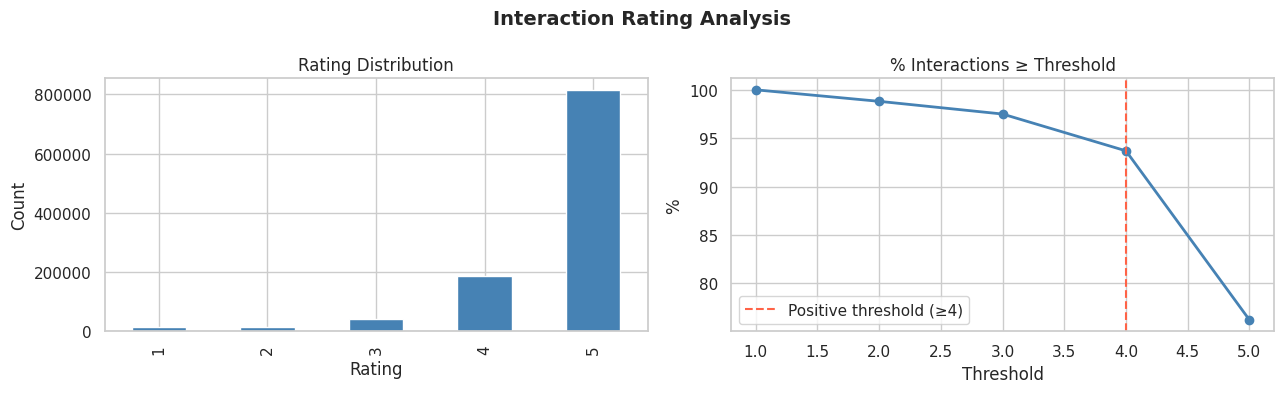

In [5]:
# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

interactions_df["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set(title="Rating Distribution", xlabel="Rating", ylabel="Count")
pcts = [(interactions_df["rating"] >= t).mean() * 100 for t in range(1, 6)]
axes[1].plot(range(1, 6), pcts, marker="o", linewidth=2, color="steelblue")
axes[1].axvline(4, ls="--", color="tomato", label="Positive threshold (≥4)")
axes[1].set(title="% Interactions ≥ Threshold", xlabel="Threshold", ylabel="%")
axes[1].legend()

plt.suptitle("Interaction Rating Analysis", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

The majority of ratings are 4–5 stars (positivity bias).

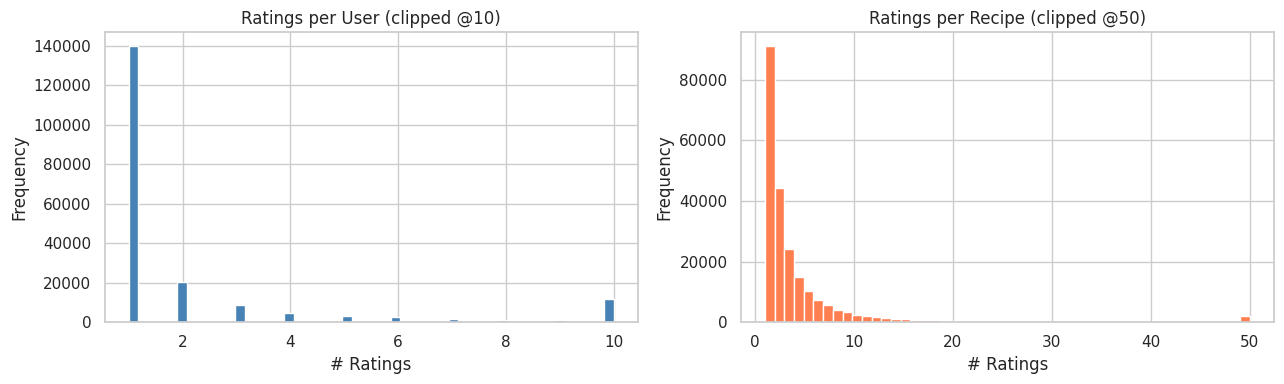

Users  with ≤2 ratings : 81.9%  — cold-start risk
Recipes with ≤2 ratings: 60.0%  — cold-start risk

min=2: 55,525 users (28.4%), 927,137 interactions (86.9%)
min=3: 35,316 users (18.1%), 886,719 interactions (83.1%)
min=5: 21,927 users (11.2%), 841,698 interactions (78.9%)
min=10: 11,984 users (6.1%), 777,297 interactions (72.9%)


In [6]:
# Cold-start analysis
user_counts = interactions_df.groupby("user_id")["recipe_id"].count()
recipe_counts = interactions_df.groupby("recipe_id")["user_id"].count()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
user_counts.clip(upper=10).plot(kind="hist", bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set(title="Ratings per User (clipped @10)", xlabel="# Ratings")
recipe_counts.clip(upper=50).plot(kind="hist", bins=50, ax=axes[1], color="coral", edgecolor="white")
axes[1].set(title="Ratings per Recipe (clipped @50)", xlabel="# Ratings")
plt.tight_layout(); plt.show()

print(f"Users  with ≤2 ratings : {(user_counts   <= 2).mean():.1%}  — cold-start risk")
print(f"Recipes with ≤2 ratings: {(recipe_counts <= 2).mean():.1%}  — cold-start risk")
print()
for min_int in [2, 3, 5, 10]:
    active = user_counts[user_counts >= min_int].index
    sub = interactions_df[interactions_df["user_id"].isin(active)]
    print(f"min={min_int}: {len(active):,} users ({len(active)/len(user_counts):.1%}), "
          f"{len(sub):,} interactions ({len(sub)/len(interactions_df):.1%})")


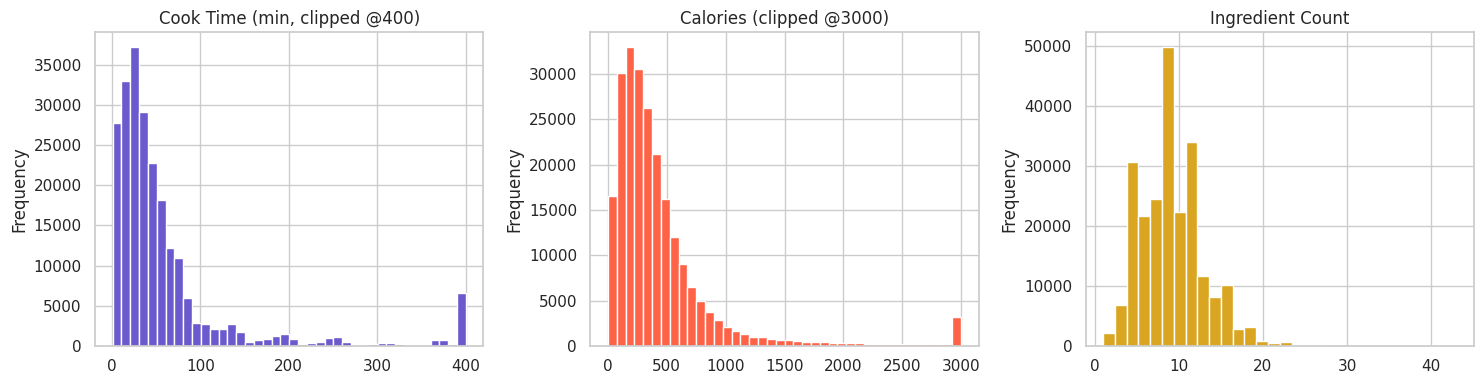

            minutes  calories  n_ingredients
count  2.301670e+05  230167.0       230167.0
mean   9.442600e+03     471.4            9.1
std    4.476189e+06    1186.5            3.7
min    1.000000e+00       0.0            1.0
25%    2.000000e+01     174.3            6.0
50%    4.000000e+01     313.1            9.0
75%    6.500000e+01     518.5           11.0
max    2.147484e+09  434360.2           43.0


In [7]:
# Recipe content distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
recipes_df["minutes"].clip(upper=400).plot(kind="hist", bins=40, ax=axes[0], color="slateblue", edgecolor="white")
axes[0].set(title="Cook Time (min, clipped @400)")
recipes_df["calories"].clip(upper=3000).plot(kind="hist", bins=40, ax=axes[1], color="tomato", edgecolor="white")
axes[1].set(title="Calories (clipped @3000)")
recipes_df["n_ingredients"].plot(kind="hist", bins=30, ax=axes[2], color="goldenrod", edgecolor="white")
axes[2].set(title="Ingredient Count")
plt.tight_layout(); plt.show()

print(recipes_df[["minutes", "calories", "n_ingredients"]].describe().round(1))

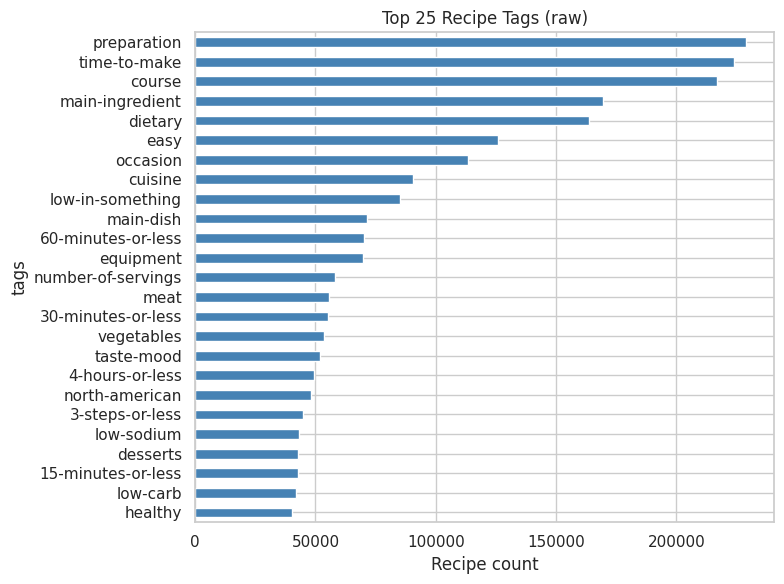

Total unique raw tags: 552
Tags appearing ≥5 times: 498
Tags appearing only once: 45  (8.2% of vocab)


In [8]:
# Top tags (raw)
raw_tag_series = (
    recipes_df['tags']
    .str.strip('[]').str.replace("'", '', regex=False)
    .str.split(',')
    .explode()
    .str.strip()
)
raw_tag_freq = raw_tag_series.value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
raw_tag_freq.head(25).sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')

ax.set(title='Top 25 Recipe Tags (raw)', xlabel='Recipe count')
plt.tight_layout()
plt.show()

print(f'Total unique raw tags: {raw_tag_freq.shape[0]:,}')
print(f'Tags appearing ≥5 times: {(raw_tag_freq >= 5).sum():,}')
print(f'Tags appearing only once: {(raw_tag_freq == 1).sum():,}  '
      f'({(raw_tag_freq == 1).mean():.1%} of vocab)')

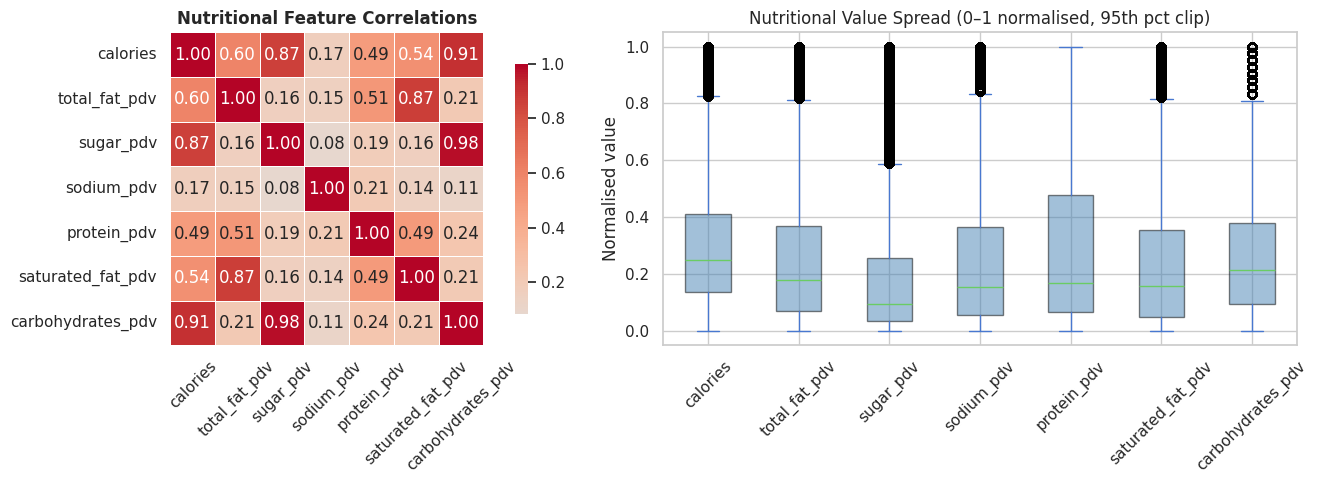

In [ ]:
# Nutrition correlation heatmap
nutri_cols_plot = ['calories', 'total_fat_pdv', 'sugar_pdv', 'sodium_pdv', 'protein_pdv', 'saturated_fat_pdv', 'carbohydrates_pdv']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

corr = recipes_df[nutri_cols_plot].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Nutritional Feature Correlations', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

quantiles = recipes_df[nutri_cols_plot].quantile(0.95)
nutri_norm = recipes_df[nutri_cols_plot].clip(upper=quantiles, axis=1)

nutri_norm = (nutri_norm - nutri_norm.min()) / (nutri_norm.max() - nutri_norm.min() + 1e-9)

nutri_norm.plot(kind='box', ax=axes[1], patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[1].set(title='Nutritional Value Spread (0–1 normalised, 95th pct clip)', ylabel='Normalised value')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

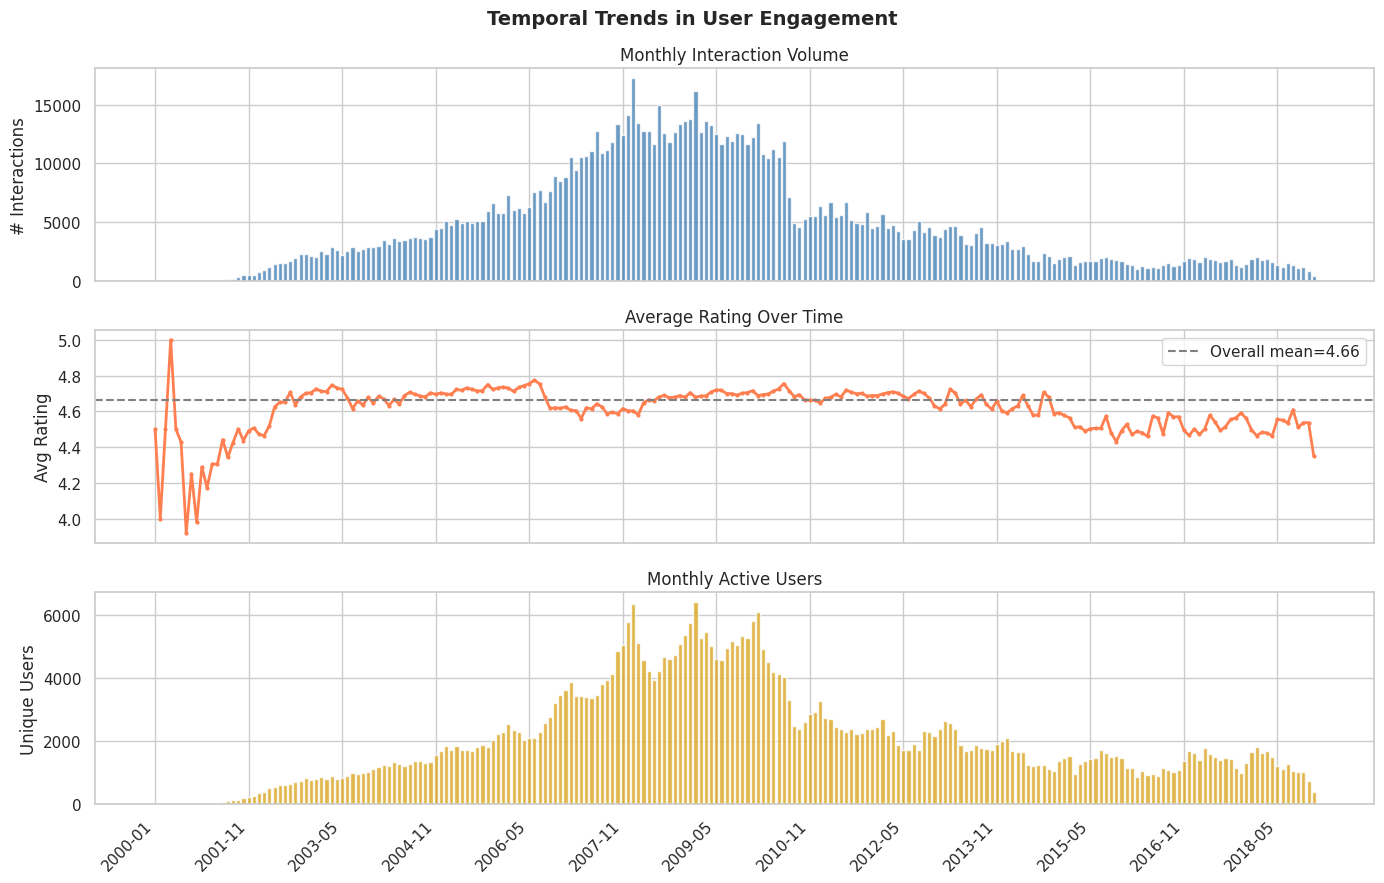

In [10]:
# Temporal trends
interactions_df['date'] = pd.to_datetime(interactions_df['date'], errors='coerce')
interactions_df['year_month'] = interactions_df['date'].dt.to_period('M')

monthly = interactions_df.groupby('year_month').agg(
    n_interactions=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    n_unique_users=('user_id', 'nunique'),
).reset_index()
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].bar(monthly['year_month_str'], monthly['n_interactions'],
            color='steelblue', alpha=0.8, width=0.8)
axes[0].set(title='Monthly Interaction Volume', ylabel='# Interactions')

axes[1].plot(monthly['year_month_str'], monthly['avg_rating'],
             color='coral', lw=2, marker='o', markersize=2)
axes[1].axhline(interactions_df['rating'].mean(), ls='--',
               color='gray', label=f'Overall mean={interactions_df["rating"].mean():.2f}')
axes[1].set(title='Average Rating Over Time', ylabel='Avg Rating')
axes[1].legend()

axes[2].bar(monthly['year_month_str'], monthly['n_unique_users'],
            color='goldenrod', alpha=0.8, width=0.8)
axes[2].set(title='Monthly Active Users', ylabel='Unique Users')

tick_step = max(1, len(monthly) // 12)
for ax in axes:
    ax.set_xticks(range(0, len(monthly), tick_step))
    ax.set_xticklabels(monthly['year_month_str'].iloc[::tick_step], rotation=45, ha='right')

plt.suptitle('Temporal Trends in User Engagement', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 4 Preprocessing

All cleaning steps run **before** the train/val/test split to prevent leakage.

| Step | What it does |
|---|---|
| 4.1 Tags | Strip meta-tags, merge misspellings, lemmatize |
| 4.2 Ingredients | Remove hardware/brands/prep words, canonicalise variants |
| 4.3 User Profiles | Parse dietary restrictions and pantry with same ingredient pipeline |
| 4.4 K-Core + Split | Min-degree filter → leave-one-out chronological split |
| 4.5 Rating Stats | `avg_rating`, `n_ratings`, `bayesian_avg` from train only |
| 4.6 Label Encoding | Integer indices for PyTorch embedding tables |
| 4.7 SBERT | Encode recipes as semantic sentences → 384-d vectors |
| 4.8 User Histories | Mean SBERT of each user's training interactions |


### 4.1 Tags

Raw tags from food.com contain structural meta-tags (`course`, `cuisine`, etc.) and misspellings. We clean them in two passes:
1. **Parse:** strip brackets/quotes and split on commas.
2. **Filter & merge:** drop meta-tags, rare tags (<2 occurrences), and overlong strings; canonicalise known misspellings via `MERGE_MAP`.

We also expand hyphenated tags (e.g. `chicken-breast` → keeps both the full tag and `chicken`) when the sub-token is frequent enough to carry its own signal.

In [11]:
# Parse raw tags
recipes_df["tags_list"] = (
    recipes_df["tags"]
    .str.strip("[]")
    .str.replace("'", "", regex=False)
    .str.replace('"', '', regex=False)
    .str.split(",")
)
recipes_df["tags_list"] = recipes_df["tags_list"].apply(
    lambda x: [t.strip() for t in x] if isinstance(x, list) else []
)

all_tags_series = recipes_df["tags_list"].explode()
tag_freq = Counter(all_tags_series.dropna())
print(f"Total tag occurrences: {len(all_tags_series):,}  |  Unique tags: {len(tag_freq):,}")
print("\nTop 30 tags:")
for tag, cnt in tag_freq.most_common(30):
    print(f"  {tag:<35}  {cnt:>6,}")

Total tag occurrences: 4,117,859  |  Unique tags: 552

Top 30 tags:
  preparation                          229,080
  time-to-make                         223,871
  course                               216,927
  main-ingredient                      169,407
  dietary                              163,792
  easy                                 125,653
  occasion                             113,306
  cuisine                              90,549
  low-in-something                     85,188
  main-dish                            71,516
  60-minutes-or-less                   69,990
  equipment                            69,835
  number-of-servings                   58,319
  meat                                 55,720
  30-minutes-or-less                   55,077
  vegetables                           53,560
  taste-mood                           52,027
  4-hours-or-less                      49,497
  north-american                       48,134
  3-steps-or-less                      44,794
  low

In [12]:
# Tag filtering rules & merge map
# Meta-tags like "course" or "cuisine" are structural category headers, not meaningful recipe attributes. We drop them and any tag appearing < 2 times.
META_TAGS = {
    "course", "cuisine", "dietary", "equipment", "main-ingredient", "occasion",
    "preparation", "time-to-make", "number-of-servings", "taste-mood",
    "technique", "presentation",
}

def is_garbage(tag: str) -> bool:
    if not tag or len(tag) < 3: return True
    if tag in META_TAGS: return True
    if len(tag) > 60: return True
    if re.search(r'[<>{}\n]', tag): return True
    if tag_freq[tag] < 2: return True
    return False

# merges for common misspellings / duplicates
MERGE_MAP = {
    "healthy-2": "healthy",
    "simply-potatoes2": "simply-potatoes",
    "rosh-hashana": "rosh-hashanah",
    "superbowl": "super-bowl",
    "lasagne": "lasagna",
}

def clean_tags(tags: list) -> list:
    if not isinstance(tags, list): return []
    cleaned = set()
    for t in tags:
        if is_garbage(t): continue
        lemmatized = lemmatizer.lemmatize(t)
        canonical  = MERGE_MAP.get(lemmatized, lemmatized)
        cleaned.add(canonical)
        # add sub-tokens of hyphenated tags that appear frequently on their own
        if "-" in canonical:
            for sub in canonical.split("-"):
                if not is_garbage(sub) and tag_freq.get(sub, 0) > 10:
                    cleaned.add(lemmatizer.lemmatize(sub))
    return sorted(cleaned)

recipes_df["tags_clean"] = recipes_df["tags_list"].apply(clean_tags)
recipes_df["tag_str"] = recipes_df["tags_clean"].apply(" ".join)
display(recipes_df[["id", "tags_clean"]].head())

,id,tags_clean
0,137739,"[60-minutes-or-less, american, christmas, easy..."
1,31490,"[30-minutes-or-less, american, breakfast, easy..."
2,112140,"[4-hours-or-less, chili, crock-pot-slow-cooker..."
3,59389,"[60-minutes-or-less, brunch, cheese, christmas..."
4,44061,"[4-hours-or-less, american, amish-mennonite, c..."


### 4.2 Ingredients

The raw ingredient list mixes food items with kitchen equipment, brand names, and prep-style adjectives. Cleaning pipeline:
1. **Remove** hardware noise (foil, skewers, …) and brand names.
2. **Strip** measurements, numbers, and prep adjectives via regex.
3. **Lemmatize:** `tomatoes` → `tomato`, `oats` → `oat`.
4. **Canonicalise:** `chicken stock` → `chicken broth`, `soya sauce` → `soy sauce`, etc.

This ensures ingredient overlap between pantry and recipe is computed in the same token space.

In [13]:
# Noise sets: hardware, brands, prep words, canonical map
HARDWARE_NOISE = {
    "aluminum foil","bag","baking sheet","balloon","bamboo skewer","bath soap",
    "bleach","borax","bottle","bowl","candy mold","cedar plank","charcoal",
    "cheesecloth","clean jar","clay flower pot","coffee filter","corn husk",
    "cotton ball","dish detergent","divided","dry ice","fabric softener",
    "flower pot","foil liner","garden trowel","hair conditioner","hickory chip",
    "hydrogen peroxide","kitchen twine","kitty litter box","laundry detergent",
    "lollipop stick","lye","measuring cup","mouthwash","napkin","new kitty litter box",
    "oak chip","oven bag","paper cup","paper towel","paraffin wax","parchment paper",
    "petroleum jelly","plastic wrap","pooper scooper","popsicle mold","potash",
    "ribbon","roasting bag","rubbing alcohol","saucepan","skewer","skillet",
    "soda straw","spray bottle","spray varnish","string","tape","toothpick",
    "washing soda","wax paper","wire rack","wood chip","wooden skewer",
}

BRANDS = [
    "absolut","ahmed","allwhites","alouette","andes","annies","aunt janes",
    "bacardi","baileys","bakers","barilla","becel","best foods","betty crocker",
    "bisquick","bob evans","campbell","campbells","del monte","doritos",
    "duncan hines","fritos","goya","heinz","hellmanns","hershey","hersheys",
    "hidden valley","hunts","jif","jiffy","kelloggs","kings hawaiian","knorr",
    "kraft","krazy up","lipton","mccormick","mccormicks","nabisco","nestl",
    "nestle","ocean spray","old el paso","oscar mayer","pace","pam",
    "pepperidge farm","philadelphia","pillsbury","prego","progresso","ragu",
    "reeses","rotel","skippy","smirnoff","smuckers","staceys","starkist",
    "swanson","tyson","v8","velveeta","vlasic","wyler","yoplait","ziploc",
]

PREP_WORDS_TO_DROP = [
    "active","all purpose","all-purpose","and","another","any","best","blanched",
    "boiling","bottled","braeburn","brand","bulb","cap","chopped","chunks",
    "clove","cloves","color","colored","concentrate","cooking","crushed","cube",
    "cubed","cubes","desired","diced","ear","ears","evaporated","extra",
    "extra-firm","extra-sharp","extra-virgin","extract","favorite","firm",
    "flavor","flavored","for","from","gala","granny smith","granulated",
    "grated","ground","half","halves","head","heads","heavy","in","into",
    "jarred","jumbo","large","leaf","leaves","mashed","medium","melted",
    "mild","minced","mini","mixed","natural","of","or","packed","peeled",
    "piece","pieces","pitted","powdered","premium","prepared","pure","pureed",
    "quality","refrigerated","seeded","seedless","separated","sharp",
    "shredded","sifting","size","slice","sliced","slivered","small","soft",
    "softened","sprig","sprigs","stalk","stalks","stick","store-bought","strips",
    "style","tart","thick","thin","top","tops","torn","undrained","unpeeled",
    "virgin","warm","washed","with","your",
]

INGRED_MAP = {
    "boiling water":"water","cold water":"water","hot water":"water","ice water":"water",
    "active dry yeast":"yeast","fast rise yeast":"yeast","instant yeast":"yeast","dry yeast":"yeast",
    "green bell pepper":"bell pepper","red bell pepper":"bell pepper","yellow bell pepper":"bell pepper",
    "white onion":"onion","yellow onion":"onion","red onion":"onion","sweet onion":"onion",
    "scallion":"green onion","spring onion":"green onion",
    "cherry tomato":"tomato","grape tomato":"tomato","plum tomato":"tomato","roma tomato":"tomato",
    "russet potato":"potato","red potato":"potato","white potato":"potato","yukon gold potato":"potato",
    "flat parsley":"parsley","italian parsley":"parsley","parsley flake":"parsley",
    "rolled oat":"oat","quick oat":"oat","old fashioned oat":"oat","steel cut oat":"oat",
    "plain flour":"flour","unbleached flour":"flour","white flour":"flour","wheat flour":"flour",
    "confectioner sugar":"sugar","confectioners sugar":"sugar","icing sugar":"sugar",
    "white sugar":"sugar","caster sugar":"sugar",
    "chicken stock":"chicken broth","low sodium chicken broth":"chicken broth",
    "beef stock":"beef broth","vegetable stock":"vegetable broth",
    "whipping cream":"cream","double cream":"cream","thickened cream":"cream",
    "soya sauce":"soy sauce","tamari":"soy sauce","low sodium soy sauce":"soy sauce",
    "gingerroot":"ginger","baby spinach":"spinach","broccoli floret":"broccoli",
    "catsup":"ketchup","tomato ketchup":"ketchup","cool whip":"whipped cream",
    "miracle whip":"mayonnaise","pizza crust":"crust","sausage patty":"sausage",
    "absolut vodka":"vodka","philadelphia cream cheese":"cream cheese",
}

MOD_PATTERN = re.compile(r'\b(' + '|'.join(re.escape(w) for w in PREP_WORDS_TO_DROP + BRANDS) + r')\b', re.IGNORECASE)
NUMBER_PATTERN = re.compile(r'\b\d+([x%]|(-\w+)|(\.\d+))?\b', re.IGNORECASE)
MEASURE_PATTERN = re.compile(
    r'\b(inch|minute|calorie|oz|lb|ounce|pound|proof|cube|cup|tbsp|tsp|tablespoon|teaspoon|gallon|quart|pint|ml|liter)s?\b',
    re.IGNORECASE)

In [14]:
def clean_ingredients(ingred_list) -> list:
    """
    Canonicalise a raw ingredient list into clean, lemmatized tokens.
    Removes hardware, brands, measurements, and prep adjectives.
    Maps common variants to a single canonical form via INGRED_MAP.
    """
    if not isinstance(ingred_list, list): return []
    cleaned = set()
    for item in ingred_list:
        item = item.lower().strip()
        # Fix common misspellings
        item = (item.replace("chilies","chili").replace("chilis","chili").replace("chile","chili")
                    .replace("cooky","cookie").replace("yoghurt","yogurt")
                    .replace("a.1.","steak sauce").replace("a1","steak sauce"))
        for sub in [x.strip() for x in item.split(" and ")]:
            if sub in HARDWARE_NOISE: continue
            core = NUMBER_PATTERN.sub('', sub)
            core = MEASURE_PATTERN.sub('', core)
            core = MOD_PATTERN.sub('', core)
            core = re.sub(r'[%&.*?]', '', core)
            core = re.sub(r'^-+', '', core)
            core = re.sub(r'-+', ' ', core)
            core = re.sub(r'\s+', ' ', core).strip()
            if len(core) < 2: continue
            lemmatized = " ".join(lemmatizer.lemmatize(w) for w in core.split())
            final = INGRED_MAP.get(lemmatized, lemmatized)
            if final: cleaned.add(final)
    return sorted(cleaned)

recipes_df["ingredients_list"] = (
    recipes_df["ingredients"]
    .str.strip("[]")
    .str.replace("'", "", regex=False)
    .str.replace('"', '', regex=False)
    .str.split(",")
)
recipes_df["ingredients_list"] = recipes_df["ingredients_list"].apply(
    lambda x: [i.strip() for i in x] if isinstance(x, list) else []
)
recipes_df["ingredients_clean"] = recipes_df["ingredients_list"].apply(clean_ingredients)

ingred_freq = Counter(recipes_df["ingredients_clean"].explode().dropna())
print(f"Unique ingredients after cleaning: {len(ingred_freq):,}")
print("\nTop 20 cleaned ingredients:")
for ing, cnt in ingred_freq.most_common(20):
    print(f"  {ing:<28}  {cnt:>6,}")

Unique ingredients after cleaning: 12,324

Top 20 cleaned ingredients:
  salt                          100,563
  onion                         61,905
  sugar                         58,936
  butter                        54,697
  garlic                        54,346
  egg                           50,458
  flour                         46,642
  water                         42,334
  olive oil                     40,305
  pepper                        38,363
  milk                          28,053
  vanilla                       24,653
  tomato                        22,187
  cinnamon                      20,119
  brown sugar                   18,691
  black pepper                  17,764
  baking powder                 17,403
  green onion                   16,253
  parmesan cheese               14,778
  lemon juice                   14,186


### 4.3 User Profiles

Pantry ingredients are parsed and cleaned with the **same pipeline** as recipe ingredients, guaranteeing that set intersection (`pantry ∩ recipe_ingredients`) is computed on identical tokens.

Dietary restriction strings are stored as-is; they're used as hard-filter keys in Stage 3.

In [15]:
# Parse pantry with the same ingredient pipeline as recipes
profiles_df["user_id"] = profiles_df["user_id"].astype(str)

profiles_df["available_ingredients"] = (
    profiles_df["available_ingredients"]
    .apply(lambda v: ast.literal_eval(str(v)) if pd.notna(v) else [])
    .apply(clean_ingredients)
    .apply(repr)
)

print(f"Profile columns: {[c for c in profiles_df.columns if c != 'user_id']}")
display(profiles_df.head(3))


Profile columns: ['diet_restriction', 'available_ingredients']


,user_id,diet_restriction,available_ingredients
0,38094,none,"['bell pepper', 'black eyed pea', 'black olive..."
1,1293707,none,"['baking soda', 'black pepper', 'butter', 'car..."
2,8937,none,"['baking soda', 'black pepper', 'butter', 'cel..."


### 4.4 K-Core Filtering & Time-Based Split

**K-Core filtering** iteratively removes users and recipes below a minimum interaction threshold until the graph stabilises.

**Why k-core?**
- ALS and BPR need enough co-rated items to learn stable latent representations.
- Users/recipes with <5 interactions add noise without contributing usable signal.
- The iterative loop is needed because removing a user can drop a recipe below threshold and vice versa.

**Time-based split** is applied after filtering. Sorting by date and using leave-one-out ensures
the model can never see future interactions during training.

In [16]:
# Filter users/recipes with too few interactions
MIN_USER_RATINGS = 5
MIN_RECIPE_RATINGS = 5
print(f"Original: {len(interactions_df):,} interactions")

filtered_df = interactions_df.copy()
iteration = 1

while True:
    start_len = len(filtered_df)
    
    user_counts = filtered_df["user_id"].value_counts()
    valid_users = user_counts[user_counts >= MIN_USER_RATINGS].index
    filtered_df = filtered_df[filtered_df["user_id"].isin(valid_users)]
    
    recipe_counts = filtered_df["recipe_id"].value_counts()
    valid_recipes = recipe_counts[recipe_counts >= MIN_RECIPE_RATINGS].index
    filtered_df = filtered_df[filtered_df["recipe_id"].isin(valid_recipes)]
    
    print(f"  [Loop {iteration}] Down to {len(filtered_df):,} interactions...")
    
    if len(filtered_df) == start_len:
        print("  K-Core balance achieved.")
        break
        
    iteration += 1

filtered_df = filtered_df.reset_index(drop=True)

print(f"\nFiltered : {len(filtered_df):,} interactions ({len(filtered_df)/len(interactions_df):.1%} retained)")
print(f"Users    : {filtered_df['user_id'].nunique():,}  |  Recipes: {filtered_df['recipe_id'].nunique():,}")

Original: 1,066,869 interactions
  [Loop 1] Down to 553,201 interactions...
  [Loop 2] Down to 533,808 interactions...
  [Loop 3] Down to 533,091 interactions...
  [Loop 4] Down to 533,024 interactions...
  [Loop 5] Down to 533,008 interactions...
  [Loop 6] Down to 533,008 interactions...
  K-Core balance achieved.

Filtered : 533,008 interactions (50.0% retained)
Users    : 16,973  |  Recipes: 39,842


### 4.4.1 K-Core Impact Analysis

The k-core filter ensures every user has ≥`MIN_USER_RATINGS` ratings **and** every recipe has ≥`MIN_RECIPE_RATINGS` ratings — enforced iteratively until stable.

This is important because:
- **ALS** needs enough co-rated items to learn meaningful latent factors.
- **LightGBM** features like `avg_rating` and `bayesian_avg` need a minimum support to be reliable.
- **BPR training** relies on sampling negatives from the same interaction space.

Below we compare the interaction graph before and after filtering.

In [17]:
# K-Core: before vs after
before_users = interactions_df['user_id'].nunique()
before_recipes = interactions_df['recipe_id'].nunique()
before_ints = len(interactions_df)
before_density = before_ints / (before_users * before_recipes)

after_users = filtered_df['user_id'].nunique()
after_recipes = filtered_df['recipe_id'].nunique()
after_ints = len(filtered_df)
after_density = after_ints / (after_users * after_recipes)

print('=' * 55)
print(f"{'Metric':<25} {'Before':>10} {'After':>10} {'Δ':>6}")
print('-' * 52)
print(f"{'Users':<25} {before_users:>10,} {after_users:>10,} "
      f"{after_users/before_users - 1:>+6.1%}")
print(f"{'Recipes':<25} {before_recipes:>10,} {after_recipes:>10,} "
      f"{after_recipes/before_recipes - 1:>+6.1%}")
print(f"{'Interactions':<25} {before_ints:>10,} {after_ints:>10,} "
      f"{after_ints/before_ints - 1:>+6.1%}")
print(f"{'Matrix Density':<25} {before_density:>10.6%} {after_density:>10.6%} "
      f"{after_density/before_density - 1:>+6.1%}")
print('=' * 55)

Metric                        Before      After      Δ
----------------------------------------------------
Users                        195,257     16,973 -91.3%
Recipes                      225,248     39,842 -82.3%
Interactions               1,066,869    533,008 -50.0%
Matrix Density             0.002426%  0.078820% +3149.3%


In [18]:
# Degree distribution: before vs after
uc_before = interactions_df.groupby('user_id')['recipe_id'].count()
uc_after  = filtered_df.groupby('user_id')['recipe_id'].count()
rc_before = interactions_df.groupby('recipe_id')['user_id'].count()
rc_after  = filtered_df.groupby('recipe_id')['user_id'].count()

print('Before filtering:')
print(f'  Users:   min={uc_before.min()}, median={uc_before.median():.0f}, mean={uc_before.mean():.1f}, max={uc_before.max()}')
print(f'  Recipes: min={rc_before.min()}, median={rc_before.median():.0f}, mean={rc_before.mean():.1f}, max={rc_before.max()}')
print('After filtering:')
print(f'  Users:   min={uc_after.min()}, median={uc_after.median():.0f}, mean={uc_after.mean():.1f}, max={uc_after.max()}')
print(f'  Recipes: min={rc_after.min()}, median={rc_after.median():.0f}, mean={rc_after.mean():.1f}, max={rc_after.max()}')


Before filtering:
  Users:   min=1, median=1, mean=5.5, max=7656
  Recipes: min=1, median=2, mean=4.7, max=1496
After filtering:
  Users:   min=5, median=10, mean=31.4, max=2775
  Recipes: min=5, median=8, mean=13.4, max=990


In [19]:
# Chronological leave-one-out split
# test = last interaction per user (never seen during training)
# val = second-to-last  (used for early stopping / hyper-param tuning)
# train = everything else

filtered_df = filtered_df.sort_values(["user_id", "date"]).reset_index(drop=True)

test_interactions  = filtered_df.drop_duplicates(subset=["user_id"], keep="last").copy()
train_interactions = filtered_df.drop(test_interactions.index).copy()
val_interactions   = train_interactions.drop_duplicates(subset=["user_id"], keep="last").copy()
train_interactions = train_interactions.drop(val_interactions.index).copy()

print(f"Train: {len(train_interactions):,}  |  Val: {len(val_interactions):,}  |  Test: {len(test_interactions):,}")

Train: 499,062  |  Val: 16,973  |  Test: 16,973


### 4.5 Rating Stats (train-only)

We compute `avg_rating`, `n_ratings`, and a **Bayesian average** from the **training split only**.

The Bayesian average shrinks noisy per-recipe means toward the global mean for recipes with few reviews:
```
bayesian_avg = (m × global_mean + avg_rating × n_ratings) / (n_ratings + m)
```
With `m=10`, a recipe with 1 review gets heavily smoothed; one with 100 reviews is barely affected.
This is the popularity signal used in cold-start retrieval and LightGBM ranking.

In [20]:
# ── Compute avg_rating / n_ratings / bayesian_avg
rating_stats = (
    train_interactions
    .groupby("recipe_id")["rating"]
    .agg(avg_rating="mean", n_ratings="count")
    .reset_index()
)
rating_stats["recipe_id"] = rating_stats["recipe_id"].astype(str)
recipes_df["id"] = recipes_df["id"].astype(str)
recipes_df = recipes_df.merge(rating_stats, left_on="id", right_on="recipe_id", how="left")
recipes_df["avg_rating"] = recipes_df["avg_rating"].fillna(recipes_df["avg_rating"].median())
recipes_df["n_ratings"]  = recipes_df["n_ratings"].fillna(0)

m = 10
global_mean  = recipes_df["avg_rating"].mean()
recipes_df["bayesian_avg"] = (
    (m * global_mean + recipes_df["avg_rating"] * recipes_df["n_ratings"])
    / (recipes_df["n_ratings"] + m)
)
print(recipes_df[["avg_rating", "n_ratings", "bayesian_avg"]].describe().round(2))

       avg_rating  n_ratings  bayesian_avg
count   230167.00  230167.00     230167.00
mean         4.79       2.17          4.78
std          0.12      10.37          0.05
min          1.83       0.00          3.68
25%          4.80       0.00          4.79
50%          4.80       0.00          4.79
75%          4.80       0.00          4.79
max          5.00     907.00          4.97


### 4.6 Label Encoding

PyTorch embedding tables require integer indices, not string IDs. We fit `LabelEncoder` on `filtered_df` (the k-core-filtered set) and apply the same
transform to train/val/test splits. This ensures consistent indexing across all splits.

In [21]:
# Integer-encode user_id and recipe_id for PyTorch embedding tables
user_encoder   = LabelEncoder()
recipe_encoder = LabelEncoder()

filtered_df["user_idx"] = user_encoder.fit_transform(filtered_df["user_id"])
filtered_df["recipe_idx"] = recipe_encoder.fit_transform(filtered_df["recipe_id"])

for split_df in [train_interactions, val_interactions, test_interactions]:
    split_df["user_id"] = split_df["user_id"].astype(str)
    split_df["recipe_id"] = split_df["recipe_id"].astype(str)
    split_df["user_idx"] = user_encoder.transform(split_df["user_id"])
    split_df["recipe_idx"] = recipe_encoder.transform(split_df["recipe_id"])

num_users = len(user_encoder.classes_)
num_recipes = len(recipe_encoder.classes_)
print(f"Encoded {num_users:,} users  and  {num_recipes:,} recipes")

Encoded 16,973 users  and  39,842 recipes


### 4.7 SBERT Encoding

We encode each recipe as a natural-language sentence using `all-MiniLM-L6-v2` (384-d):
```
"<recipe_name>: ingredient_1, ingredient_2, ... | tag_1, tag_2, ..."
```

In [22]:
# Build recipe sentences
def recipe_to_sentence(row) -> str:
    name = str(row.get("name", "")).strip()
    ings = ", ".join(row["ingredients_clean"]) if isinstance(row.get("ingredients_clean"), list) else ""
    tags = ", ".join(row["tags_clean"]) if isinstance(row.get("tags_clean"), list) else ""
    return f"{name}: {ings} | {tags}"

recipe_sentences = [recipe_to_sentence(row) for _, row in recipes_df.iterrows()]
print(f"Built {len(recipe_sentences):,} recipe sentences.")
print("Example:", recipe_sentences[0])

Built 230,167 recipe sentences.
Example: arriba   baked winter squash mexican style: butter, honey, mexican seasoning, olive oil, salt, spice, winter squash | 60-minutes-or-less, american, christmas, easy, fall, holiday-event, mexican, north-american, seasonal, side-dishes, squash, vegetable, vegetarian, winter


In [23]:
# Encode with SBERT
sbert = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
sbert_vectors = sbert.encode(
    recipe_sentences,
    batch_size=512,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
)
print(f"SBERT vectors: {sbert_vectors.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/450 [00:00<?, ?it/s]

SBERT vectors: (230167, 384)


In [24]:
# Build text_dict: recipe_idx → 384-d SBERT vector
target_type = type(recipe_encoder.classes_[0])
valid_recipe_ids = set(recipe_encoder.classes_)
text_dict = {}

for i, (_, row) in enumerate(recipes_df.iterrows()):
    try: r_id = target_type(row["id"])
    except: continue
    if r_id not in valid_recipe_ids: continue
    r_idx = recipe_encoder.transform([r_id])[0]
    text_dict[r_idx] = sbert_vectors[i]

# edge case: id type mismatch
zero_hist = np.zeros(SBERT_DIM, dtype=np.float32)
for r_idx in range(num_recipes):
    if r_idx not in text_dict:
        text_dict[r_idx] = zero_hist.copy()

missing = sum(1 for v in text_dict.values() if not np.any(v))
print(f"text_dict: {len(text_dict):,} recipes  ({missing:,} zero-vector fallbacks)")

text_dict: 39,842 recipes  (0 zero-vector fallbacks)


### 4.8 User History Vectors

For each user, we compute the **mean SBERT vector** across all their training interactions. This serves as a fixed content-based taste profile — the *history tower* input to the Two-Tower.

It complements the learned collaborative ID embedding: even for users whose ID embedding is undertrained (sparse interactions), the history vector provides meaningful signal.

In [25]:
# Mean SBERT of each user's training interactions
user_history_text: dict = {}
for u_idx, grp in tqdm(train_interactions.groupby("user_idx"), desc="user history"):
    vecs = [text_dict[r] for r in grp["recipe_idx"].values if r in text_dict]
    user_history_text[u_idx] = np.mean(vecs, axis=0).astype(np.float32) if vecs else zero_hist.copy()

print(f"History vectors: {len(user_history_text):,} users  |  dim={SBERT_DIM}")


user history: 100%|██████████| 16973/16973 [00:02<00:00, 6396.94it/s]

History vectors: 16,973 users  |  dim=384


---
## 5 Stage 1: Retrieval

**Goal:** Efficiently retrieve ~100 plausible recipe candidates per user from 180k+ recipes.

We train and compare two retrievers:

| Model | Mechanism | Strength | Weakness |
|---|---|---|---|
| **ALS** | Matrix factorisation | Pure collaborative signal, fast | Ignores recipe content |
| **Two-Tower** | CF embedding + SBERT | Fuses user behaviour + content | Slower to train |

ALS serves as a useful baseline. The Two-Tower is used in the final pipeline.

### 5.1 ALS Baseline

Alternating Least Squares on an implicit confidence matrix. We treat rating ≥ 4 as a positive signal and apply BM25-style confidence weighting. This gives us a fast collaborative filtering baseline to compare against the Two-Tower.

In [26]:
# Sparse user-item matrix (positive interactions only)
# Rating ≥ 4 = positive implicit signal.
# Confidence = 1 + alpha * rating

ALS_FACTORS = EMBED_DIM
ALS_ITERS = 20
ALS_ALPHA = 40

pos_train = train_interactions[train_interactions["rating"] >= 4].copy()

user_item_matrix = csr_matrix(
    (1 + ALS_ALPHA * pos_train["rating"].values,
     (pos_train["recipe_idx"].values, pos_train["user_idx"].values)),
    shape=(num_recipes, num_users),
)

als_model = implicit.als.AlternatingLeastSquares(
    factors=ALS_FACTORS, iterations=ALS_ITERS, use_gpu=False, random_state=42
)
als_model.fit(user_item_matrix)

  0%|          | 0/20 [00:00<?, ?it/s]

In [27]:
# ALS Recall@K
user_item_T = user_item_matrix.T.tocsr() # (n_users, n_recipes)
test_users = test_interactions["user_idx"].values
test_targets = test_interactions["recipe_idx"].values

als_hits = 0
for u_val, target in zip(test_users, test_targets):
    recs, _ = als_model.recommend(u_val, user_item_T[u_val], N=K_RETRIEVAL, filter_already_liked_items=False)
    als_hits += int(target in recs)

print(f"ALS Recall@{K_RETRIEVAL}: {als_hits / len(test_users):.2%}")

ALS Recall@100: 0.33%


### 5.2 Two-Tower Model

**User Tower:** ID embedding → FC → concat with SBERT history mean → output.

**Recipe Tower:** ID embedding → concat with projected SBERT vector → output.

**Score:** dot product of both tower outputs.

**Key design choices:**
- **BPR loss** with N=4 random negatives. We avoid in-batch negatives because food is a high-overlap domain — other users' positives are frequently false negatives.
- **Cosine annealing LR** + early stopping (`PATIENCE=5`) prevents overfitting.
- **L2-normalised embeddings at inference:** `get_user_vec` / `get_item_vec` both call `F.normalize`, so the dot product is equivalent to cosine similarity.

In [28]:
class RecipeTwoTower(nn.Module):
    def __init__(self, num_users, num_recipes, text_dim, embed_dim=128):
        super().__init__()
        # User tower
        self.user_embedding = nn.Embedding(num_users, embed_dim)
        self.user_fc = nn.Linear(embed_dim, embed_dim)
        self.history_fc = nn.Linear(text_dim, embed_dim)
        self.user_out_fc = nn.Linear(embed_dim * 2, embed_dim)
        
        # Recipe tower
        self.recipe_embedding = nn.Embedding(num_recipes, embed_dim)
        self.text_fc = nn.Linear(text_dim, embed_dim)
        self.item_fc = nn.Linear(embed_dim * 2, embed_dim)
        
        self.dropout = nn.Dropout(p=0.2)

    def _user_vec(self, user_idx, hist_vec):
        u = F.relu(self.user_fc(self.user_embedding(user_idx)))
        h = F.relu(self.history_fc(hist_vec))
        return F.relu(self.user_out_fc(torch.cat([u, h], dim=1)))

    def _item_vec(self, recipe_idx, text_features):
        r = self.recipe_embedding(recipe_idx)
        t = F.relu(self.text_fc(text_features))
        return F.relu(self.item_fc(torch.cat([r, t], dim=1)))

    def forward(self, user_idx, recipe_idx, text_features, hist_vec):
        u_vec = self.dropout(self._user_vec(user_idx, hist_vec))
        i_vec = self.dropout(self._item_vec(recipe_idx, text_features))
        return (u_vec * i_vec).sum(dim=1)

    def get_user_vec(self, user_idx, hist_vec):
        u = F.relu(self.user_fc(self.user_embedding(user_idx)))
        h = F.relu(self.history_fc(hist_vec))
        return F.normalize(F.relu(self.user_out_fc(torch.cat([u, h], dim=1))), dim=1)

    def get_item_vec(self, recipe_idx, text_features):
        r = self.recipe_embedding(recipe_idx)
        t = F.relu(self.text_fc(text_features))
        return F.normalize(F.relu(self.item_fc(torch.cat([r, t], dim=1))), dim=1)

In [29]:
# Dataset: N_NEG random negatives per positive
N_NEG = 4

class RecipeDataset(Dataset):
    def __init__(self, interactions_df, all_recipe_indices, text_dict, user_history_text, presample=False):
        self.users = interactions_df["user_idx"].values
        self.recipes = interactions_df["recipe_idx"].values
        self.all_recipes = all_recipe_indices
        self.text_dict = text_dict
        self.user_history = user_history_text
        self.user_seen = interactions_df.groupby("user_idx")["recipe_idx"].apply(set).to_dict()
        self.zero_hist = np.zeros(SBERT_DIM, dtype=np.float32)
        self._cache = None
        
        if presample:
            self._cache = [self._sample(i) for i in range(len(self.users))]

    def _sample(self, idx):
        user = self.users[idx]
        pos = self.recipes[idx]
        seen = self.user_seen.get(user, set())
        negs = []
        
        while len(negs) < N_NEG:
            neg = random.choice(self.all_recipes)
            if neg not in seen:
                negs.append(neg)
                
        hist = self.user_history.get(user, self.zero_hist)
        
        return {
            "user_idx": torch.tensor(user, dtype=torch.long),
            "pos_idx": torch.tensor(pos, dtype=torch.long),
            "neg_indices": torch.tensor(negs, dtype=torch.long),
            "pos_text": torch.tensor(self.text_dict[pos], dtype=torch.float32),
            "neg_texts": torch.tensor([self.text_dict[n] for n in negs], dtype=torch.float32),
            "hist_vec": torch.tensor(hist, dtype=torch.float32),
        }

    def __len__(self):  
        return len(self.users)
        
    def __getitem__(self, idx): 
        if self._cache:
            return self._cache[idx]
        return self._sample(idx)

In [30]:
BATCH_SIZE = 512
EPOCHS = 20
LR = 5e-4
PATIENCE = 5
TEMP = 20.0  

all_recipe_indices = list(recipe_encoder.transform(recipe_encoder.classes_))
model = RecipeTwoTower(num_users, num_recipes, text_dim=SBERT_DIM, embed_dim=EMBED_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

train_ds = RecipeDataset(train_interactions, all_recipe_indices, text_dict, user_history_text, presample=False)
val_ds = RecipeDataset(val_interactions, all_recipe_indices, text_dict, user_history_text, presample=True)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

best_val_loss = float("inf")
patience_ctr = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    for batch in train_dl:
        ui = batch["user_idx"].to(device)
        pi = batch["pos_idx"].to(device)
        ni = batch["neg_indices"].to(device)
        pt = batch["pos_text"].to(device)
        nt = batch["neg_texts"].to(device)
        hv = batch["hist_vec"].to(device)
        
        B = ui.shape[0]
        optimizer.zero_grad()

        u_vec = F.normalize(model.dropout(model._user_vec(ui, hv)), dim=1)
        pos_vec = F.normalize(model.dropout(model._item_vec(pi, pt)), dim=1)
        pos_s = (u_vec * pos_vec).sum(dim=1)
        
        neg_vec = F.normalize(model.dropout(model._item_vec(ni.view(-1), nt.view(-1, SBERT_DIM))), dim=1)
        neg_vec = neg_vec.view(B, N_NEG, EMBED_DIM)
        neg_s = torch.bmm(u_vec.unsqueeze(1), neg_vec.transpose(1, 2)).squeeze(1)

        loss = -F.logsigmoid((pos_s.unsqueeze(1) - neg_s) * TEMP).mean()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch in val_dl:
            ui = batch["user_idx"].to(device)
            pi = batch["pos_idx"].to(device)
            ni = batch["neg_indices"].to(device)
            pt = batch["pos_text"].to(device)
            nt = batch["neg_texts"].to(device)
            hv = batch["hist_vec"].to(device)
            
            B = ui.shape[0]
            
            u_vec = F.normalize(model._user_vec(ui, hv), dim=1)
            pos_vec = F.normalize(model._item_vec(pi, pt), dim=1)
            pos_s = (u_vec * pos_vec).sum(dim=1)
            
            neg_vec = F.normalize(model._item_vec(ni.view(-1), nt.view(-1, SBERT_DIM)), dim=1)
            neg_vec = neg_vec.view(B, N_NEG, EMBED_DIM)
            neg_s = torch.bmm(u_vec.unsqueeze(1), neg_vec.transpose(1, 2)).squeeze(1)
            
            val_loss += (-F.logsigmoid((pos_s.unsqueeze(1) - neg_s) * TEMP).mean()).item()

    avg_tr = train_loss / len(train_dl)
    avg_val = val_loss / len(val_dl)
    lr_now = scheduler.get_last_lr()[0]
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train: {avg_tr:.4f} | Val: {avg_val:.4f} | LR: {lr_now:.2e}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), "/tmp/best_model.pt")
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stop at epoch {epoch+1} (best val={best_val_loss:.4f})")
            break
            
    scheduler.step()

model.load_state_dict(torch.load("/tmp/best_model.pt"))

Epoch 01/20 | Train: 0.6663 | Val: 0.5241 | LR: 5.00e-04
Epoch 02/20 | Train: 0.5604 | Val: 0.4768 | LR: 4.97e-04
Epoch 03/20 | Train: 0.5224 | Val: 0.4546 | LR: 4.88e-04
Epoch 04/20 | Train: 0.5065 | Val: 0.4503 | LR: 4.73e-04
Epoch 05/20 | Train: 0.4946 | Val: 0.4385 | LR: 4.53e-04
Epoch 06/20 | Train: 0.4838 | Val: 0.4337 | LR: 4.28e-04
Epoch 07/20 | Train: 0.4742 | Val: 0.4331 | LR: 3.99e-04
Epoch 08/20 | Train: 0.4689 | Val: 0.4289 | LR: 3.66e-04
Epoch 09/20 | Train: 0.4625 | Val: 0.4290 | LR: 3.31e-04
Epoch 10/20 | Train: 0.4569 | Val: 0.4248 | LR: 2.93e-04
Epoch 11/20 | Train: 0.4532 | Val: 0.4259 | LR: 2.55e-04
Epoch 12/20 | Train: 0.4493 | Val: 0.4242 | LR: 2.17e-04
Epoch 13/20 | Train: 0.4453 | Val: 0.4262 | LR: 1.79e-04
Epoch 14/20 | Train: 0.4422 | Val: 0.4256 | LR: 1.44e-04
Epoch 15/20 | Train: 0.4395 | Val: 0.4254 | LR: 1.11e-04
Epoch 16/20 | Train: 0.4374 | Val: 0.4258 | LR: 8.18e-05
Epoch 17/20 | Train: 0.4353 | Val: 0.4268 | LR: 5.68e-05
Early stop at epoch 17 (best va

<All keys matched successfully>

### 5.3 Pre-compute Recipe Universe

We pre-compute all recipe embeddings once and cache the result. This avoids re-encoding 180k+ recipes on every query — retrieval then reduces to a
single matrix multiply: `user_vec @ recipe_universe.T`.

In [31]:
# Recipe universe: unnormalised item embeddings (n_recipes × EMBED_DIM)
all_r_t  = torch.tensor(all_recipe_indices, dtype=torch.long).to(device)
all_t_t  = torch.tensor(np.array([text_dict[r] for r in all_recipe_indices]), dtype=torch.float32).to(device)

model.eval()
chunks = []
with torch.no_grad():
    for i in tqdm(range(0, num_recipes, 1024), desc="recipe_universe"):
        r_c = all_r_t[i:i+1024]; t_c = all_t_t[i:i+1024]
        chunks.append(F.normalize(F.relu(model.item_fc(torch.cat([
            model.recipe_embedding(r_c), F.relu(model.text_fc(t_c))], dim=1))), dim=1))
recipe_universe = torch.cat(chunks, dim=0)   # stays on device
print(f"recipe_universe: {recipe_universe.shape}  on {recipe_universe.device}")

recipe_universe: 100%|██████████| 39/39 [00:00<00:00, 2777.45it/s]

recipe_universe: torch.Size([39842, 128])  on cuda:0


### 5.4 Retrieval Evaluation

We measure **Recall@100** on the held-out test set: did the true next recipe appear in the top-100 candidates returned by each retriever?

In [32]:
# Two-Tower Recall@K on the test set
tt_hits = 0
model.eval()
with torch.no_grad():
    for u_val, target in zip(test_users, test_targets):
        u_t = torch.tensor([u_val], dtype=torch.long).to(device)
        hist = torch.tensor(user_history_text.get(u_val, zero_hist), dtype=torch.float32).unsqueeze(0).to(device)
        u_vec = model.get_user_vec(u_t, hist)
        top_k = torch.topk(torch.matmul(u_vec, recipe_universe.T).squeeze(), k=K_RETRIEVAL).indices.cpu().numpy()
        tt_hits += int(target in top_k)

tt_recall = tt_hits / len(test_users)
print(f"\nRetrieval Recall@{K_RETRIEVAL}")
print(f"  ALS: {als_hits/len(test_users):.2%}")
print(f"  Two-Tower: {tt_recall:.2%}")


Retrieval Recall@100
  ALS: 0.33%
  Two-Tower: 10.15%


---
## 6 Feature Engineering

We build three categories of features for the LightGBM ranker:

| Category | Features | Purpose |
|---|---|---|
| **Recipe metadata** | nutrition, cook time, popularity | Absolute recipe quality |
| **User nutritional profile** | `\|recipe_val − user_avg_{col}\|` for 8 nutrients | Personalised nutrition matching |
| **Pantry overlap** | `\|profile_pantry ∩ recipe_ingredients\| / \|recipe_ingredients\|` | Feasibility signal |

User profiles are built from **training data only** to prevent leakage.
Pantry is **augmented** during training (20% random drops + up to 3 random adds) to
prevent the model over-fitting to perfect overlap and to handle noisy real-world pantries.

In [33]:
# Recipe metadata features
RECIPE_FEATURES = ["id", "minutes", "n_ingredients", "calories",
                   "total_fat_pdv", "sugar_pdv", "sodium_pdv", "protein_pdv",
                   "saturated_fat_pdv", "carbohydrates_pdv",
                   "avg_rating", "n_ratings", "bayesian_avg"]

recipe_metadata = recipes_df[RECIPE_FEATURES].copy()
recipe_metadata["id"] = recipe_metadata["id"].astype(str)
print("recipe_metadata shape:", recipe_metadata.shape)

recipe_metadata shape: (230167, 13)


In [34]:
# Per-user nutritional profiles (train only)
# Used to compute personalised diff features for the ranker.
user_profiles_hist = (
    train_interactions
    .assign(recipe_id=lambda d: d["recipe_id"].astype(str))
    .merge(recipes_df[["id"] + NUTRI_COLS], left_on="recipe_id", right_on="id", how="left")
    .groupby("user_idx")[NUTRI_COLS]
    .mean()
    .rename(columns={c: f"user_avg_{c}" for c in NUTRI_COLS})
    .reset_index()
)
print(f"user_profiles_hist: {user_profiles_hist.shape}")
print(user_profiles_hist.drop(columns="user_idx").describe().round(2).to_string())

user_profiles_hist: (16973, 9)
       user_avg_calories  user_avg_total_fat_pdv  user_avg_sugar_pdv  user_avg_sodium_pdv  user_avg_protein_pdv  user_avg_saturated_fat_pdv  user_avg_carbohydrates_pdv  user_avg_minutes
count           16973.00                16973.00            16973.00             16973.00              16973.00                    16973.00                    16973.00      1.697300e+04
mean              459.38                   34.44               74.49                33.80                 38.28                       44.45                       14.55      2.281418e+04
std               338.06                   32.77               90.97                46.81                 40.23                       41.75                       12.08      1.304502e+06
min                37.53                    0.00                0.00                 0.00                  0.00                        0.00                        0.00      3.670000e+00
25%               326.95               

In [35]:
# Ingredient lookup tables
def _parse_ing_set(val) -> frozenset:
    if isinstance(val, (list, np.ndarray, set, frozenset)):
        return frozenset(str(v).strip() for v in val if v)
    try:
        result = ast.literal_eval(str(val).strip())
        if isinstance(result, (list, set, frozenset)):
            return frozenset(str(x).strip() for x in result if x)
    except:
        pass
    return frozenset()

RECIPE_ING: dict[str, frozenset] = {
    str(row["id"]): frozenset(row["ingredients_clean"])
    for _, row in tqdm(recipes_df.iterrows(), total=len(recipes_df), desc="RECIPE_ING")
}

pantry_lookup: dict[str, frozenset] = {
    str(row["user_id"]): _parse_ing_set(row.get("available_ingredients", "[]"))
    for _, row in profiles_df.iterrows()
}

profiled = sum(1 for p in pantry_lookup.values() if p)
print(f"pantry_lookup  : {profiled:,}/{len(pantry_lookup):,}")
print(f"RECIPE_ING size: {len(RECIPE_ING):,}")

RECIPE_ING: 100%|██████████| 230167/230167 [00:09<00:00, 23250.77it/s]


pantry_lookup  : 195,257/195,257
RECIPE_ING size: 230,167


In [36]:
# Pantry augmentation
ALL_INGREDIENTS = sorted({ing for ings in RECIPE_ING.values() for ing in ings})
print(f"Ingredient pool: {len(ALL_INGREDIENTS):,} unique ingredients")

def augment_pantry_lookup(base_lookup: dict, p_drop: float = 0.2, max_add: int = 3, seed: int = 42) -> dict:
    rng = np.random.default_rng(seed)
    aug = {}
    for uid, pantry in base_lookup.items():
        if not pantry:
            aug[uid] = pantry
            continue
        kept = frozenset(ing for ing in pantry if rng.random() > p_drop)
        n_add = int(rng.integers(0, max_add + 1))
        if n_add:
            kept = kept | frozenset(rng.choice(ALL_INGREDIENTS, size=n_add, replace=False))
        aug[uid] = kept
    return aug

Ingredient pool: 12,324 unique ingredients


> During training we randomly drop 20% of pantry items and add up to 3 noise ingredients. This prevents the ranker from over-fitting to perfect pantry overlapand makes it more robust to real users who don't update their pantry precisely.

In [37]:
# Feature helper functions
def add_pantry_overlap(df: pd.DataFrame, pantry_override: dict = None) -> pd.DataFrame:
    lookup = pantry_override if pantry_override is not None else pantry_lookup
    df = df.copy()
    if "user_id_str" not in df.columns:
        df["user_id_str"] = user_encoder.inverse_transform(df["user_idx"].values).astype(str)
    pantries = df["user_id_str"].map(lambda u: lookup.get(u, frozenset()))
    ing_sets = df["original_recipe_id"].astype(str).map(lambda r: RECIPE_ING.get(r, frozenset()))
    df["pantry_overlap"] = [len(p & r) / len(r) if r else 0.0 for p, r in zip(pantries, ing_sets)]
    return df

def add_nutri_diffs(df: pd.DataFrame) -> pd.DataFrame:
    """Merge user nutritional averages (train-only) and compute per-dim absolute diffs."""
    drop = [c for c in df.columns if c.startswith("user_avg_") or c.endswith("_diff")]
    df = df.drop(columns=drop, errors="ignore")
    df = df.merge(user_profiles_hist, on="user_idx", how="left")
    for col in NUTRI_COLS:
        df[f"{col}_diff"] = abs(df[col] - df[f"user_avg_{col}"])
    return df

### 6.1 Generate LightGBM Candidate Set

For each training user, we retrieve their top-`K_RETRIEVAL` candidates from the Two-Tower and label any that appear in their training interactions as positive, rest as negative.

In [38]:
# Top-K candidates per train user → LightGBM training rows
K = K_RETRIEVAL
true_interactions = train_interactions.groupby("user_idx")["recipe_idx"].apply(set).to_dict()
rows_list = []

model.eval()
with torch.no_grad():
    for u_idx in tqdm(train_interactions["user_idx"].unique(), desc="Generating candidates"):
        u_t = torch.tensor([u_idx], dtype=torch.long).to(device)
        hist = torch.tensor(user_history_text.get(u_idx, zero_hist), dtype=torch.float32).unsqueeze(0).to(device)
        u_vec = model.get_user_vec(u_t, hist)
        scores = torch.matmul(u_vec, recipe_universe.T).squeeze()
        top_k = torch.topk(scores, k=K).indices.cpu().numpy()
        top_s = scores[top_k].cpu().numpy()
        for rank, (r_idx, s) in enumerate(zip(top_k, top_s), 1):
            rows_list.append({
                "user_idx": u_idx, "recipe_idx": r_idx,
                "pytorch_score": s, "pytorch_rank": rank,
            })

lgbm_df = pd.DataFrame(rows_list)
lgbm_df["original_recipe_id"] = recipe_encoder.inverse_transform(lgbm_df["recipe_idx"]).astype(str)
lgbm_df = lgbm_df.merge(recipe_metadata, left_on="original_recipe_id", right_on="id", how="left")
print(f"Candidate set: {len(lgbm_df):,} rows  ({K} per user × {train_interactions['user_idx'].nunique():,} users)")

Generating candidates: 100%|██████████| 16973/16973 [00:15<00:00, 1080.80it/s]


Candidate set: 1,697,300 rows  (100 per user × 16,973 users)


In [39]:
# Feature engineering to candidate sets
aug_lookup = augment_pantry_lookup(pantry_lookup, p_drop=0.2, max_add=3)

lgbm_df = add_nutri_diffs(add_pantry_overlap(lgbm_df, pantry_override=aug_lookup))
lgbm_df = lgbm_df.fillna(0)

# Val candidates
val_rows = []
model.eval()
with torch.no_grad():
    for u_idx in tqdm(val_interactions["user_idx"].unique(), desc="Val candidates"):
        u_t = torch.tensor([u_idx], dtype=torch.long).to(device)
        hist = torch.tensor(user_history_text.get(u_idx, zero_hist),
                            dtype=torch.float32).unsqueeze(0).to(device)
        scores = torch.matmul(model.get_user_vec(u_t, hist), recipe_universe.T).squeeze()
        top_k  = torch.topk(scores, k=K).indices.cpu().numpy()
        top_s  = scores[top_k].cpu().numpy()
        for rank, (r_idx, s) in enumerate(zip(top_k, top_s), 1):
            val_rows.append({"user_idx": u_idx, "recipe_idx": r_idx,
                             "pytorch_score": s, "pytorch_rank": rank})

lgbm_val_cands = pd.DataFrame(val_rows)
lgbm_val_cands["original_recipe_id"] = recipe_encoder.inverse_transform(lgbm_val_cands["recipe_idx"]).astype(str)
lgbm_val_cands = lgbm_val_cands.merge(recipe_metadata, left_on="original_recipe_id", right_on="id", how="left")
lgbm_val_cands = add_nutri_diffs(add_pantry_overlap(lgbm_val_cands))
lgbm_val_cands = lgbm_val_cands.fillna(0)

print(f"lgbm_df: {len(lgbm_df):,}  |  lgbm_val_cands: {len(lgbm_val_cands):,}")
print(f"\npantry_overlap > 0:  train={(lgbm_df['pantry_overlap']>0).mean():.1%}"
      f"  val={(lgbm_val_cands['pantry_overlap']>0).mean():.1%}")

Val candidates: 100%|██████████| 16973/16973 [00:15<00:00, 1077.94it/s]


lgbm_df: 1,697,300  |  lgbm_val_cands: 1,697,300

pantry_overlap > 0:  train=90.7%  val=93.8%


---
## 7 Stage 2: Ranking (LightGBM LambdaRank)

LightGBM with `objective='lambdarank'` directly optimises NDCG over the Stage-1 candidate lists.

**Why LambdaRank on top of the Two-Tower?**

The Two-Tower optimises BPR. LambdaRank:
- Directly optimises the evaluation metric (NDCG@10).
- Can express cross-features like `|user_avg_calories − recipe_calories|` without adding a feature interaction layer to the neural model.
- Is fast to train and easy to interpret via feature importance.

In [40]:
NUTRI_DIFF_FEATURES = [f"{c}_diff" for c in NUTRI_COLS]

lgbm_features = [
    "pytorch_score", "pytorch_rank",
    "minutes", "n_ingredients", "calories",
    "total_fat_pdv", "sugar_pdv", "sodium_pdv", "protein_pdv",
    "saturated_fat_pdv", "carbohydrates_pdv",
    "bayesian_avg",
    *NUTRI_DIFF_FEATURES,
    "pantry_overlap",
]
print(f"{len(lgbm_features)} features: {lgbm_features}")

21 features: ['pytorch_score', 'pytorch_rank', 'minutes', 'n_ingredients', 'calories', 'total_fat_pdv', 'sugar_pdv', 'sodium_pdv', 'protein_pdv', 'saturated_fat_pdv', 'carbohydrates_pdv', 'bayesian_avg', 'calories_diff', 'total_fat_pdv_diff', 'sugar_pdv_diff', 'sodium_pdv_diff', 'protein_pdv_diff', 'saturated_fat_pdv_diff', 'carbohydrates_pdv_diff', 'minutes_diff', 'pantry_overlap']


In [41]:
pos_pairs = (train_interactions[["user_idx","recipe_idx"]].assign(label=1).drop_duplicates())
lgbm_df = lgbm_df.merge(pos_pairs, on=["user_idx","recipe_idx"], how="left")
lgbm_df["label"] = lgbm_df["label"].fillna(0).astype("int32")

lgbm_df = lgbm_df.sort_values("user_idx").reset_index(drop=True)
labels = lgbm_df["label"].values
group = lgbm_df.groupby("user_idx").size().values.tolist()

train_data = lgb.Dataset(lgbm_df[lgbm_features], label=labels, group=group)
print(f"Training set: {len(lgbm_df):,} rows  |  {len(group):,} groups  |"
      f"  pos_rate={labels.mean():.3%}")

Training set: 1,697,300 rows  |  16,973 groups  |  pos_rate=2.239%


In [42]:
params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [10],
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_bin": 127,
    "min_data_in_leaf": 30,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbosity": -1,
}
ranker = lgb.train(params, train_data, num_boost_round=300)

               feature  importance
          minutes_diff        1263
        sugar_pdv_diff        1161
saturated_fat_pdv_diff        1157
       sodium_pdv_diff        1150
      protein_pdv_diff        1145
carbohydrates_pdv_diff        1140
        pantry_overlap        1119
         pytorch_score        1109
          pytorch_rank         951
    total_fat_pdv_diff         950
         calories_diff         858
          bayesian_avg         825
               minutes         786
             sugar_pdv         714
           protein_pdv         708
     saturated_fat_pdv         689
            sodium_pdv         619
         total_fat_pdv         601
         n_ingredients         596
              calories         559
     carbohydrates_pdv         500


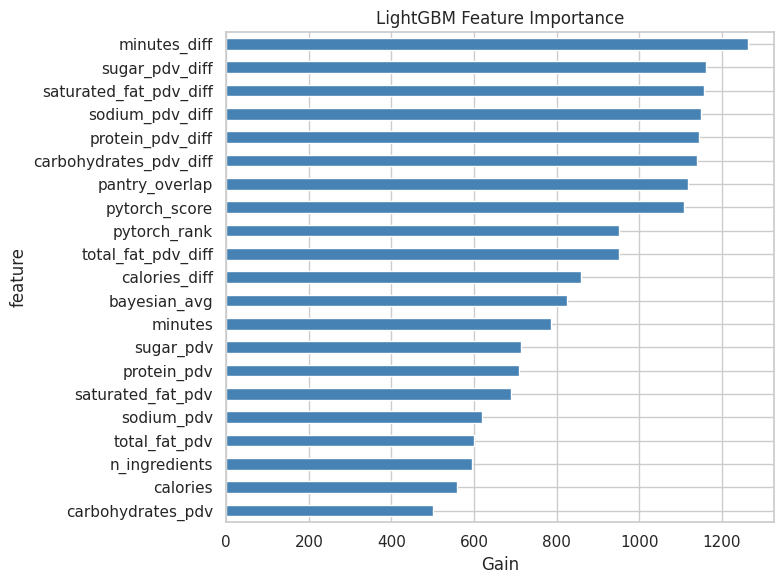

In [43]:
# Feature importance
imp = (pd.DataFrame({"feature": lgbm_features, "importance": ranker.feature_importance()}).sort_values("importance", ascending=False))
print(imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
imp.sort_values("importance").plot(kind="barh", x="feature", y="importance", ax=ax, color="steelblue", legend=False)
ax.set(title="LightGBM Feature Importance", xlabel="Gain")
plt.tight_layout(); plt.show()

In [44]:
# Val evaluation
lgbm_val_cands["lgbm_score"] = ranker.predict(lgbm_val_cands[lgbm_features])
lgbm_val_cands = lgbm_val_cands.sort_values(["user_idx","lgbm_score"], ascending=[True,False])
lgbm_val_cands["lgbm_rank"] = lgbm_val_cands.groupby("user_idx").cumcount() + 1

hits_val = val_interactions[["user_idx","recipe_idx"]].merge(lgbm_val_cands[["user_idx","recipe_idx","lgbm_rank","pytorch_rank"]],on=["user_idx","recipe_idx"], how="inner")
hits_val["lgbm_ndcg"] = 1.0 / np.log2(hits_val["lgbm_rank"] + 1)
hits_val["pytorch_ndcg"] = 1.0 / np.log2(hits_val["pytorch_rank"] + 1)

print(f"VAL SET  (K={K_EVAL})")
print(f"Two-Tower  Recall@{K_EVAL}: {(hits_val['pytorch_rank']<=K_EVAL).mean():.2%}"
      f"  |  NDCG@{K_EVAL}: {hits_val['pytorch_ndcg'].mean():.4f}")
print(f"LightGBM   Recall@{K_EVAL}: {(hits_val['lgbm_rank']<=K_EVAL).mean():.2%}"
      f"  |  NDCG@{K_EVAL}: {hits_val['lgbm_ndcg'].mean():.4f}")
print("\nLightGBM should show a clear NDCG improvement over raw Two-Tower ordering.")

VAL SET  (K=10)
Two-Tower  Recall@10: 21.75%  |  NDCG@10: 0.2535
LightGBM   Recall@10: 35.64%  |  NDCG@10: 0.3261

LightGBM should show a clear NDCG improvement over raw Two-Tower ordering.


---
## 8 Stage 3: Re-ranking (MMR)

After LightGBM ranks the candidates, the top-N results can still be homogeneous. We apply **Maximal Marginal Relevance (MMR)** to balance relevance with diversity.

**MMR scoring per candidate `i`:**
```
score(i) = λ · normalised_lgbm_score(i)  −  (1−λ) · max_{j ∈ Selected} cos_sim(i, j)
```

| λ | Behaviour |
|---|---|
| 1.0 | Pure relevance (NDCG-optimal) |
| 0.0 | Pure diversity |
| **0.7** | **Default: relevance-first with diversity penalty** |

Similarity is cosine over unit-normalised SBERT vectors, computed once at init.
Diet hard-filter runs **before** MMR so the diversity pool is already diet-compliant.

---
## 9 Pipeline

### 9.1 RecipeRecommender

The `RecipeRecommender` class encapsulates all three stages. It handles:
- Stage 1 retrieval via pre-computed `recipe_universe`.
- Stage 2 ranking with full feature engineering.
- Stage 3 MMR re-ranking with diet hard-filter.

It also supports `nutri_override` for new users who haven't built a training
profile yet, and accepts an explicit `pantry` frozenset so the caller controls
which pantry to use (profile, fridge override, or empty).

In [45]:
RECIPE_FEATURES_FOR_DISPLAY = ["id", "n_ingredients", *NUTRI_COLS, "avg_rating", "n_ratings", "bayesian_avg"]
recipe_metadata_display = recipes_df[RECIPE_FEATURES_FOR_DISPLAY].copy()
recipe_metadata_display["id"] = recipe_metadata_display["id"].astype(str)

class RecipeRecommender:
    def __init__(self, pytorch_model, lgbm_ranker, encoders, dataframes, text_dict, user_history_text, recipe_diet_index, recipe_universe, device):
        self.model = pytorch_model
        self.ranker = lgbm_ranker
        self.user_encoder, self.recipe_encoder = encoders
        self.recipes_df, self.profiles_df, self.recipe_metadata, self.user_profiles_hist = dataframes
        self.text_dict = text_dict
        self.user_history_text = user_history_text
        self.recipe_diet_index = recipe_diet_index
        self.device = device
        self.recipe_universe = recipe_universe
        self.lgbm_features = lgbm_features
        self.zero_hist = np.zeros(SBERT_DIM, dtype=np.float32)

        # Pre-compute normalized SBERT vectors for MMR diversity scoring
        all_r_idx = list(self.recipe_encoder.transform(self.recipe_encoder.classes_))
        vecs = np.array([self.text_dict[r] for r in all_r_idx], dtype=np.float32)
        norms = np.linalg.norm(vecs, axis=1, keepdims=True).clip(min=1e-9)
        self.sbert_norm = vecs / norms
        print(f"RecipeRecommender ready | recipe_universe={self.recipe_universe.shape}")

    def _add_pantry(self, df: pd.DataFrame, pantry: frozenset) -> pd.DataFrame:
        ing_sets = df["original_recipe_id"].astype(str).map(
            lambda r: RECIPE_ING.get(r, frozenset())
        )
        df["pantry_overlap"] = [len(pantry & r) / len(r) if r else 0.0 for r in ing_sets]
        return df

    def _add_nutri_diffs(self, df: pd.DataFrame, nutri_override: dict = None) -> pd.DataFrame:
        if nutri_override is not None:
            for col in NUTRI_COLS:
                avg = nutri_override.get(f"user_avg_{col}", self.recipe_metadata[col].mean())
                df[f"user_avg_{col}"] = avg
                df[f"{col}_diff"] = abs(df[col] - avg)
        else:
            df = df.merge(self.user_profiles_hist, on="user_idx", how="left")
            for col in NUTRI_COLS:
                fallback = self.recipe_metadata[col].mean()
                df[f"{col}_diff"] = abs(df[col] - df[f"user_avg_{col}"].fillna(fallback))
        return df

    # Stage 1

    def stage1_retrieve(self, u_idx: int, K: int = K_RETRIEVAL) -> pd.DataFrame:
        """Retrieve top-K candidates for a known user."""
        u_t = torch.tensor([u_idx], dtype=torch.long).to(self.device)
        hist_array = self.user_history_text.get(u_idx, self.zero_hist)
        hist = torch.tensor(hist_array, dtype=torch.float32).unsqueeze(0).to(self.device)
        
        self.model.eval()
        with torch.no_grad():
            u_vec = self.model.get_user_vec(u_t, hist)
            scores = torch.matmul(u_vec, self.recipe_universe.T).squeeze()
            
        top_k = torch.topk(scores, k=K).indices.cpu().numpy()
        top_s = scores[top_k].cpu().numpy()
        
        df = pd.DataFrame({
            "recipe_idx": top_k,
            "pytorch_score": top_s,
            "pytorch_rank": np.arange(1, K + 1),
        })
        
        df["original_recipe_id"] = self.recipe_encoder.inverse_transform(df["recipe_idx"]).astype(str)
        return df.merge(self.recipe_metadata, left_on="original_recipe_id", right_on="id", how="left")

    def stage1_retrieve_from_hist(self, hist_np: np.ndarray, K: int = K_RETRIEVAL) -> pd.DataFrame:
        """Retrieve using a precomputed history vector (for Tier 2 new users)."""
        dummy_u = torch.zeros(1, dtype=torch.long).to(self.device)
        hist_t = torch.tensor(hist_np, dtype=torch.float32).unsqueeze(0).to(self.device)
        
        self.model.eval()
        with torch.no_grad():
            u_vec = self.model.get_user_vec(dummy_u, hist_t)
            scores = torch.matmul(u_vec, self.recipe_universe.T).squeeze()
            
        top_k = torch.topk(scores, k=K).indices.cpu().numpy()
        top_s = scores[top_k].cpu().numpy()
        
        df = pd.DataFrame({
            "recipe_idx": top_k,
            "pytorch_score": top_s,
            "pytorch_rank": np.arange(1, K + 1),
        })
        
        df["original_recipe_id"] = self.recipe_encoder.inverse_transform(df["recipe_idx"]).astype(str)
        return df.merge(self.recipe_metadata, left_on="original_recipe_id", right_on="id", how="left")

    # Stage 2

    def stage2_rank(self, candidates_df: pd.DataFrame, u_idx: int = None, pantry: frozenset = frozenset(), nutri_override: dict = None) -> pd.DataFrame:
        df = candidates_df.copy()
        if u_idx is not None:
            df["user_idx"] = u_idx
            
        df = self._add_nutri_diffs(df, nutri_override=nutri_override)
        df = self._add_pantry(df, pantry)
        df = df.fillna(0)
        
        df["lgbm_score"] = self.ranker.predict(df[self.lgbm_features])
        return df.sort_values("lgbm_score", ascending=False).reset_index(drop=True)

    # Stage 3

    def stage3_rerank(self, ranked_df: pd.DataFrame, diets=None, top_n: int = 10, lam: float = 0.7) -> pd.DataFrame:
        """Diet hard-filter → MMR re-sort for relevance-diversity balance."""
        df = ranked_df.copy()

        # Hard filter — only keep recipes suitable for all requested diets
        if diets:
            for d in diets:
                valid = {rid for rid, ds in self.recipe_diet_index.items() if d in ds}
                df = df[df["original_recipe_id"].isin(valid)]
                
        if df.empty:
            return df.head(top_n)

        idxs = df["recipe_idx"].values
        scores = df["lgbm_score"].values
        
        s_min = scores.min()
        s_max = scores.max()
        norm_s = (scores - s_min) / (s_max - s_min + 1e-9)

        vecs = self.sbert_norm[idxs]
        selected = []
        remaining = list(range(len(idxs)))

        while len(selected) < top_n and remaining:
            if not selected:
                best = max(remaining, key=lambda i: norm_s[i])
            else:
                sel_v = vecs[selected]
                best = max(
                    remaining,
                    key=lambda i: (lam * norm_s[i] - (1.0 - lam) * float((vecs[i] @ sel_v.T).max()))
                )
            selected.append(best)
            remaining.remove(best)

        return df.iloc[selected].reset_index(drop=True)

    def serve(self, user_id_str: str, top_n: int = 10, diets=None, fridge=None, lam: float = 0.7) -> pd.DataFrame:
        try:    
            u_idx = self.user_encoder.transform([str(user_id_str)])[0]
        except ValueError: 
            return pd.DataFrame({"error": [f"Unknown user: {user_id_str}"]})

        diets_clean = [d.lower() for d in diets] if diets else None
        
        if fridge:
            pantry = frozenset(fridge)
        else:
            pantry = pantry_lookup.get(str(user_id_str), frozenset())

        s1 = self.stage1_retrieve(u_idx)
        s2 = self.stage2_rank(s1, u_idx=u_idx, pantry=pantry)
        
        s2 = s2.merge(
            self.recipes_df[["id", "name", "ingredients_clean", "tags_clean"]],
            left_on="original_recipe_id", 
            right_on="id", 
            how="left", 
            suffixes=("", "_r")
        )
        
        final = self.stage3_rerank(s2, diets=diets_clean, top_n=top_n, lam=lam)
        cols = [c for c in ["name", "calories", "minutes", "pantry_overlap", "lgbm_score"] if c in final.columns]
        
        return final[cols].reset_index(drop=True)

### 9.2 Recipe Diet Index

In [46]:
# Build diet index from suitable_diets column
recipe_diet_index = {
    str(row["id"]): frozenset(
        ast.literal_eval(str(row["suitable_diets"])) if pd.notna(row.get("suitable_diets")) else []
    )
    for _, row in recipes_df.iterrows()
}

diet_counts = {}
for ds in recipe_diet_index.values():
    for d in ds:
        diet_counts[d] = diet_counts.get(d, 0) + 1

print(f"Diet index: {len(recipe_diet_index):,} recipes")
print("Diet coverage:", {d: f"{c:,}" for d, c in sorted(diet_counts.items(), key=lambda x: -x[1])})

Diet index: 230,167 recipes
Diet coverage: {'nut_allergy': '196,120', 'no_tomatoes': '190,283', 'vegetarian': '146,406', 'gluten_free': '145,217', 'no_onions_garlic': '121,771', 'lactose_intolerant': '87,052', 'vegan': '40,478'}


### 9.3 Instantiate Recommender

In [47]:
recommender = RecipeRecommender(
    pytorch_model = model,
    lgbm_ranker = ranker,
    encoders = (user_encoder, recipe_encoder),
    dataframes = (recipes_df, profiles_df, recipe_metadata, user_profiles_hist),
    text_dict = text_dict,
    user_history_text = user_history_text,
    recipe_diet_index = recipe_diet_index,
    recipe_universe = recipe_universe,
    device = device,
)

sample_user = str(test_interactions["user_id"].iloc[42])
print(f"Sample user: {sample_user}")
display(recommender.serve(sample_user, top_n=5))

RecipeRecommender ready | recipe_universe=torch.Size([39842, 128])
Sample user: 6536


,name,calories,minutes,pantry_overlap,lgbm_score
0,easy creamy hamburger stroganoff,417.6,15,0.666667,1.290181
1,hamburger noodle bake,742.5,45,0.636364,1.134702
2,slow cooker cheesy chicken,241.7,490,0.333333,0.815598
3,breakfast bagel sandwiches oamc,470.9,21,0.600000,0.706705
4,the blue mill tavern loosemeat sandwich,313.8,30,0.555556,0.744453


### 9.4 Three-Tier `recommend()` + `add_interaction()`

The production API handles three user types without special-casing at the call site:

| Tier | Condition | Retrieval method |
|---|---|---|
| **1 Known** | `user_id` in encoder | Full Two-Tower vector |
| **2 New with history** | `user_id` not in encoder but has recorded interactions | History-only SBERT vector |
| **3 Cold-start** | No `user_id` or no history | Top-rated recipes in diet pool |

`add_interaction()` updates the user's history in real time and invalidates their cache entry,
so the next `recommend()` call reflects the new rating.


In [48]:
new_user_history: dict[str, list] = {}   # uid_str → [(recipe_idx, rating), ...]

def _build_new_user_hist_vec(uid_str: str) -> np.ndarray:
    items = new_user_history.get(uid_str, [])
    if not items:
        return zero_hist
        
    r_idxs = [r for r, _ in items]
    ratings = np.array([rt for _, rt in items], dtype=np.float32)
    vecs = np.array([text_dict.get(r, zero_hist) for r in r_idxs], dtype=np.float32)
    
    w = ratings / ratings.sum()
    return (vecs * w[:, None]).sum(axis=0)

def _nutri_profile_from_new_user(uid_str: str) -> dict | None:
    items = new_user_history.get(uid_str, [])
    if not items:
        return None
        
    r_idxs = [r for r, _ in items]
    r_ids = recipe_encoder.inverse_transform(r_idxs).astype(str)
    rows = recipes_df[recipes_df["id"].isin(r_ids)]
    
    if rows.empty:
        return None
        
    return {
        f"user_avg_{col}": rows[col].mean() 
        for col in NUTRI_COLS if col in rows.columns
    }


def _cold_start_candidates(rec: RecipeRecommender, diets=None, K: int = 300) -> pd.DataFrame:
    meta = rec.recipe_metadata.copy()
    
    if diets:
        for d in diets:
            valid = {rid for rid, ds in rec.recipe_diet_index.items() if d in ds}
            meta = meta[meta["id"].astype(str).isin(valid)]

    top_meta = meta.nlargest(K, "bayesian_avg")
    valid_ids = [r for r in top_meta["id"].astype(str) if r in set(rec.recipe_encoder.classes_.astype(str))]
    r_idxs = rec.recipe_encoder.transform(valid_ids)

    cands = pd.DataFrame({
        "recipe_idx": r_idxs,
        "pytorch_score": top_meta[top_meta["id"].astype(str).isin(valid_ids)]["bayesian_avg"].values[:len(r_idxs)],
        "pytorch_rank": np.arange(1, len(r_idxs) + 1),
    })
    
    cands["original_recipe_id"] = rec.recipe_encoder.inverse_transform(cands["recipe_idx"]).astype(str)
    return cands.merge(rec.recipe_metadata, left_on="original_recipe_id", right_on="id", how="left").fillna(0)


In [49]:
class RecommendationCache:
    def __init__(self): 
        self._store = {}

    def get(self, uid: str, n_int: int):
        e = self._store.get(uid)
        if e and e["n_int"] == n_int:
            return e["recs"]
        return None

    def set(self, uid: str, recs: pd.DataFrame, n_int: int):
        self._store[uid] = {
            "recs": recs, 
            "n_int": n_int, 
            "ts": time.time()
        }

    def invalidate(self, uid: str): 
        if uid in self._store:
            del self._store[uid]

cache = RecommendationCache()

In [50]:
def recommend(rec: RecipeRecommender, user_id=None, diets=None, fridge=None, top_n: int = 10, lam: float = 0.7, use_cache: bool = True) -> pd.DataFrame:
    diets_clean = [d.lower() for d in diets] if diets else None
    pantry_set = frozenset(fridge) if fridge else None
    cacheable = use_cache and not diets and not fridge

    uid_str = str(user_id) if user_id is not None else None
    u_idx = None

    if uid_str:
        try:   
            u_idx = rec.user_encoder.transform([uid_str])[0]
        except ValueError: 
            pass

    # Cache check
    if uid_str and cacheable:
        n_known = int((train_interactions["user_idx"] == u_idx).sum()) if u_idx is not None else 0
        n_new = len(new_user_history.get(uid_str, []))
        cached = cache.get(uid_str, n_known + n_new)
        if cached is not None:
            return cached.head(top_n)

    # Resolve pantry
    if pantry_set is not None:
        pantry = pantry_set
    elif uid_str:
        pantry = pantry_lookup.get(uid_str, frozenset())
    else:
        pantry = frozenset()

    # Retrieve + rank
    if u_idx is not None:
        # Tier 1
        s1 = rec.stage1_retrieve(u_idx)
        s2 = rec.stage2_rank(s1, u_idx=u_idx, pantry=pantry)

    elif uid_str and new_user_history.get(uid_str):
        # Tier 2
        hist_vec = _build_new_user_hist_vec(uid_str)
        s1 = rec.stage1_retrieve_from_hist(hist_vec)
        nutri = _nutri_profile_from_new_user(uid_str)
        s2 = rec.stage2_rank(s1, u_idx=None, pantry=pantry, nutri_override=nutri)

    else:
        # Tier 3
        cs = _cold_start_candidates(rec, diets=diets_clean)
        if pantry:
            cs = rec._add_pantry(cs, pantry)
            
        for col in NUTRI_COLS:
            global_avg = rec.recipe_metadata[col].mean()
            cs[f"user_avg_{col}"] = global_avg
            cs[f"{col}_diff"] = abs(cs[col] - global_avg)
            
        cs = cs.fillna(0)
        
        if "pantry_overlap" not in cs.columns:
            cs["pantry_overlap"] = 0.0
            
        cs["lgbm_score"] = rec.ranker.predict(cs[rec.lgbm_features])
        
        cs = cs.merge(
            rec.recipes_df[["id", "name", "ingredients_clean", "tags_clean"]],
            left_on="original_recipe_id", 
            right_on="id", 
            how="left", 
            suffixes=("", "_r")
        )
        
        final = rec.stage3_rerank(cs.sort_values("lgbm_score", ascending=False), diets=diets_clean, top_n=top_n, lam=lam)
        cols = [c for c in ["name", "calories", "minutes", "pantry_overlap", "lgbm_score"] if c in final.columns]
        return final[cols].reset_index(drop=True)

    # Tier 1 + 2 shared path
    s2 = s2.merge(
        rec.recipes_df[["id", "name", "ingredients_clean", "tags_clean"]],
        left_on="original_recipe_id", 
        right_on="id", 
        how="left", 
        suffixes=("", "_r")
    )
    
    final = rec.stage3_rerank(s2, diets=diets_clean, top_n=top_n, lam=lam)
    cols = [c for c in ["name", "calories", "minutes", "pantry_overlap", "lgbm_score"] if c in final.columns]
    result = final[cols].reset_index(drop=True)

    if uid_str and cacheable:
        n_known = int((train_interactions["user_idx"] == u_idx).sum()) if u_idx is not None else 0
        n_new = len(new_user_history.get(uid_str, []))
        cache.set(uid_str, result, n_known + n_new)

    return result

In [51]:
def add_interaction(user_id, recipe_id, rating: int):
    uid_str = str(user_id)
    rid_str = str(recipe_id)

    try:    
        r_idx = recipe_encoder.transform([rid_str])[0]
    except ValueError:
        print(f"Recipe '{rid_str}' not in encoder — skipping.")
        return

    try:
        # Tier 1: known user
        u_idx = user_encoder.transform([uid_str])[0]
        new_v = text_dict.get(r_idx, zero_hist)
        old_v = user_history_text.get(u_idx, zero_hist.copy())
        
        alpha = (rating / 5.0) * 0.15
        user_history_text[u_idx] = old_v + alpha * (new_v - old_v)

        recipe_row = recipes_df[recipes_df["id"] == rid_str]
        if not recipe_row.empty:
            mask = user_profiles_hist["user_idx"] == u_idx
            if mask.any():
                for col in NUTRI_COLS:
                    if col in recipe_row.columns:
                        old_avg = user_profiles_hist.loc[mask, f"user_avg_{col}"].values[0]
                        new_val = recipe_row[col].values[0]
                        user_profiles_hist.loc[mask, f"user_avg_{col}"] = old_avg * 0.9 + new_val * 0.1
            else:
                new_row = {"user_idx": u_idx}
                for col in NUTRI_COLS:
                    new_row[f"user_avg_{col}"] = recipe_row[col].values[0] if col in recipe_row.columns else 0.0
                user_profiles_hist.loc[len(user_profiles_hist)] = new_row

        print(f"Tier 1 — updated history for user={uid_str}")

    except ValueError:
        # Tier 2: new user
        if uid_str not in new_user_history:
            new_user_history[uid_str] = []
            
        new_user_history[uid_str].append((r_idx, rating))
        print(f"Tier 2 — new_user={uid_str}: {len(new_user_history[uid_str])} rating(s) recorded")

    cache.invalidate(uid_str)
    print(f"Recorded {rating}★ user={uid_str} recipe={rid_str} (cache invalidated)")

### 9.5 Pipeline Tests

In [52]:
# Tier 1: existing user
t0 = time.time()
display(recommend(recommender, user_id=sample_user, top_n=5))
print(f"first call : {time.time()-t0:.3f}s")

t0 = time.time()
recommend(recommender, user_id=sample_user)
print(f"cached     : {time.time()-t0:.4f}s")

,name,calories,minutes,pantry_overlap,lgbm_score
0,easy creamy hamburger stroganoff,417.6,15,0.666667,1.290181
1,hamburger noodle bake,742.5,45,0.636364,1.134702
2,slow cooker cheesy chicken,241.7,490,0.333333,0.815598
3,breakfast bagel sandwiches oamc,470.9,21,0.600000,0.706705
4,the blue mill tavern loosemeat sandwich,313.8,30,0.555556,0.744453


first call : 0.156s
cached     : 0.0022s


In [53]:
# Tier 1 with diet + fridge override
display(recommend(recommender, user_id=sample_user, diets=["vegetarian"], fridge=["garlic", "onion", "tomato"], top_n=5))

,name,calories,minutes,pantry_overlap,lgbm_score
0,pepperoni chips,138.3,30,0.00,-0.216938
1,awesome slow cooker pot roast,50.0,490,0.00,-0.387564
2,simple tomato sandwich,266.0,5,0.25,-0.364761
3,christina s killer dip,293.3,30,0.00,-0.481900
4,oven roasted corn on the cob,122.5,30,0.00,-0.536829


In [54]:
# Tier 3: anonymous cold-start
display(recommend(recommender, user_id=None, diets=["vegan"], fridge=["chickpeas", "spinach", "lemon"], top_n=5))

,name,calories,minutes,pantry_overlap,lgbm_score
0,grow your own magic doughnuts donuts,483.6,5,0.000000,-0.851241
1,caprese salad tomatoes italian marinated toma...,137.5,10,0.142857,-1.036359
2,worm sandwiches,307.6,15,0.000000,-0.858037
3,refreshing mojito by the pitcher mojitos,129.5,15,0.000000,-1.160481
4,homemade tahini,315.2,20,0.000000,-1.118401


In [55]:
# Tier 2: new user grows from cold-start to personalised
new_uid = "brand_new_user_42"

print("\n-- 0 ratings (cold-start) --")
display(recommend(recommender, user_id=new_uid, top_n=5))

add_interaction(new_uid, test_interactions["recipe_id"].iloc[0], rating=5)
print("\n-- 1 rating --")
display(recommend(recommender, user_id=new_uid, top_n=5))

add_interaction(new_uid, test_interactions["recipe_id"].iloc[1], rating=4)
add_interaction(new_uid, test_interactions["recipe_id"].iloc[2], rating=3)
print("\n-- 3 ratings (personalised) --")
display(recommend(recommender, user_id=new_uid, top_n=5))


-- 0 ratings (cold-start) --


,name,calories,minutes,pantry_overlap,lgbm_score
0,warm roasted root vegetable and chicken salad ...,507.2,50,0.0,-1.030564
1,no bake hershey s bar pie,604.3,20,0.0,-1.043551
2,the original rice krispies treats squares,116.5,10,0.0,-1.041966
3,kittencal s make ahead mashed potatoes,383.0,40,0.0,-1.055652
4,2 handed kitchen sink tomato sandwich,165.8,15,0.0,-1.174384


Tier 2 — new_user=brand_new_user_42: 1 rating(s) recorded
Recorded 5★ user=brand_new_user_42 recipe=132916 (cache invalidated)

-- 1 rating --


,name,calories,minutes,pantry_overlap,lgbm_score
0,oatmeal cottage cheese pancakes,337.1,15,0.0,0.163671
1,roasted cauliflower 16 roasted cloves of garlic,126.9,40,0.0,-0.009238
2,the ultimate greek salad,223.3,15,0.0,-0.138876
3,frizzled cabbage,130.2,25,0.0,-0.228440
4,fried brussels sprouts,163.6,15,0.0,-0.246281


Tier 2 — new_user=brand_new_user_42: 2 rating(s) recorded
Recorded 4★ user=brand_new_user_42 recipe=218471 (cache invalidated)
Tier 2 — new_user=brand_new_user_42: 3 rating(s) recorded
Recorded 3★ user=brand_new_user_42 recipe=291770 (cache invalidated)

-- 3 ratings (personalised) --


,name,calories,minutes,pantry_overlap,lgbm_score
0,vegemite on toast,151.0,5,0.0,0.585283
1,cinnamon oranges,71.2,5,0.0,0.325462
2,weight watchers milk shake flex or core,113.0,5,0.0,0.176920
3,yogurt dip for fruit,61.1,5,0.0,0.135900
4,oatmeal cottage cheese pancakes,337.1,15,0.0,0.066915


In [56]:
# Tier 1: add_interaction → cache invalidation
add_interaction(sample_user, test_interactions["recipe_id"].iloc[0], rating=5)

t0 = time.time()
recommend(recommender, user_id=sample_user, top_n=5)
print(f"post-add (re-computed): {time.time()-t0:.3f}s")

Tier 1 — updated history for user=6536
Recorded 5★ user=6536 recipe=132916 (cache invalidated)
post-add (re-computed): 0.146s


---
## 10 Test Evaluation

We measure **Recall@10** and **NDCG@10** on the held-out test set.

- **Recall@10** — did the true next recipe appear in the top-10?
- **NDCG@10** — discount by rank so top-1 is worth more than top-10.

We compare Two-Tower alone vs Two-Tower + LightGBM to quantify the ranking gain.


In [57]:
def build_test_candidates(users_iter, K=K_RETRIEVAL) -> pd.DataFrame:
    rows = []
    model.eval()
    
    with torch.no_grad():
        for u_idx in tqdm(users_iter, desc="test candidates"):
            u_t = torch.tensor([u_idx], dtype=torch.long).to(device)
            hist_array = user_history_text.get(u_idx, zero_hist)
            hist = torch.tensor(hist_array, dtype=torch.float32).unsqueeze(0).to(device)
            
            user_vec = model.get_user_vec(u_t, hist)
            scores = torch.matmul(user_vec, recipe_universe.T).squeeze()
            
            top_k = torch.topk(scores, k=K).indices.cpu().numpy()
            top_s = scores[top_k].cpu().numpy()
            
            for rank, (r_idx, s) in enumerate(zip(top_k, top_s), 1):
                rows.append({
                    "user_idx": u_idx, 
                    "recipe_idx": r_idx,
                    "pytorch_score": s, 
                    "pytorch_rank": rank
                })

    df = pd.DataFrame(rows)
    df["original_recipe_id"] = recipe_encoder.inverse_transform(df["recipe_idx"]).astype(str)
    df = df.merge(recipe_metadata, left_on="original_recipe_id", right_on="id", how="left")
    
    df = add_nutri_diffs(add_pantry_overlap(df))
    return df.fillna(0)

In [58]:
test_cands = build_test_candidates(test_interactions["user_idx"].unique())
test_cands["lgbm_score"] = ranker.predict(test_cands[lgbm_features])
test_cands = test_cands.sort_values(["user_idx", "lgbm_score"], ascending=[True, False])
test_cands["lgbm_rank"] = test_cands.groupby("user_idx").cumcount() + 1

hits = test_interactions[["user_idx", "recipe_idx"]].merge(
    test_cands[["user_idx", "recipe_idx", "lgbm_rank", "pytorch_rank"]],
    on=["user_idx", "recipe_idx"], 
    how="inner"
)

hits["lgbm_ndcg"] = 1.0 / np.log2(hits["lgbm_rank"] + 1)
hits["pytorch_ndcg"] = 1.0 / np.log2(hits["pytorch_rank"] + 1)

print(f"TEST SET  (K={K_EVAL})")
print(f"{'Model':<12}  {'Recall@'+str(K_EVAL):>12}  {'NDCG@'+str(K_EVAL):>10}")
print("-" * 38)
print(f"{'Two-Tower':<12}  {(hits['pytorch_rank']<=K_EVAL).mean():>12.2%}  {hits['pytorch_ndcg'].mean():>10.4f}")
print(f"{'LightGBM':<12}  {(hits['lgbm_rank']<=K_EVAL).mean():>12.2%}  {hits['lgbm_ndcg'].mean():>10.4f}")

recall_gain = (hits['lgbm_rank']<=K_EVAL).mean() - (hits['pytorch_rank']<=K_EVAL).mean()
ndcg_gain = hits['lgbm_ndcg'].mean() - hits['pytorch_ndcg'].mean()

print(f"\nLightGBM gain → Recall: {recall_gain:+.2%} | NDCG: {ndcg_gain:+.4f}")

test candidates: 100%|██████████| 16973/16973 [00:15<00:00, 1110.61it/s]


TEST SET  (K=10)
Model            Recall@10     NDCG@10
--------------------------------------
Two-Tower           21.25%      0.2581
LightGBM            35.02%      0.3270

LightGBM gain → Recall: +13.76% | NDCG: +0.0688


---
## 11 Save artifacts

We save everything needed to run the web demo **without** re-running this notebook:

| File | Purpose |
|---|---|
| `best_model.pt` | Two-Tower weights + architecture metadata |
| `ranker.txt` | LightGBM booster (text format) |
| `lgbm_features.pkl` | Ordered feature list for ranker.predict() |
| `encoders.pkl` | LabelEncoders for user_id and recipe_id |
| `text_dict.pkl` | SBERT vectors (recipe_idx → 384-d float32) |
| `recipe_diet_index.pkl` | recipe_id → frozenset of suitable diets |
| `recipe_universe.pt` | Pre-computed item embeddings (saves ~30s on demo restart) |
| `sbert_norm.npy` | Unit-normed SBERT vectors for MMR diversity scoring |
| `recipes.parquet` | Full recipe table (name, nutrition, ingredients, tags) |
| `profiles.parquet` | User profiles (diet restriction, pantry) |
| `interactions.parquet` | Training interactions |
| `val_interactions.parquet` | Validation interactions |
| `test_interactions.csv` | Test interactions |
| `user_history_profiles.parquet` | Per-user nutritional averages |
| `user_history_text.pkl` | Per-user mean SBERT history vectors |
| `lgbm_train_df.parquet` | LightGBM training candidate set |
| `lgbm_val_cands.parquet` | Validation candidate set |
| `test_cands.parquet` | Test candidate set with scores and ranks |


In [59]:
ARTIFACTS.mkdir(parents=True, exist_ok=True)

# Models 
torch.save({
    "state_dict": model.state_dict(),
    "num_users": num_users,
    "num_recipes": num_recipes,
    "text_dim": SBERT_DIM,
    "embed_dim": EMBED_DIM,
}, ARTIFACTS / "best_model.pt")

ranker.save_model(str(ARTIFACTS / "ranker.txt"))

with open(ARTIFACTS / "lgbm_features.pkl", "wb") as f:
    pickle.dump(lgbm_features, f)

# Encoders & Embeddings
with open(ARTIFACTS / "encoders.pkl", "wb") as f:
    pickle.dump((user_encoder, recipe_encoder), f)

with open(ARTIFACTS / "text_dict.pkl", "wb") as f:
    pickle.dump(text_dict, f)

torch.save(recipe_universe.cpu(), ARTIFACTS / "recipe_universe.pt")
np.save(str(ARTIFACTS / "sbert_norm.npy"), recommender.sbert_norm)

# Lookup tables 
with open(ARTIFACTS / "recipe_diet_index.pkl", "wb") as f:
    pickle.dump(recipe_diet_index, f)

with open(ARTIFACTS / "user_history_text.pkl", "wb") as f:
    pickle.dump(user_history_text, f)

# DataFrames 
recipes_df.to_parquet(ARTIFACTS / "recipes.parquet", index=False)
profiles_df.to_parquet(ARTIFACTS / "profiles.parquet", index=False)

train_interactions.to_parquet(ARTIFACTS / "interactions.parquet", index=False)
val_interactions.to_parquet(ARTIFACTS / "val_interactions.parquet", index=False)
test_interactions.to_csv(ARTIFACTS / "test_interactions.csv", index=False)

user_profiles_hist.to_parquet(ARTIFACTS / "user_history_profiles.parquet", index=False)

lgbm_df.to_parquet(ARTIFACTS / "lgbm_train_df.parquet", index=False)
lgbm_val_cands.to_parquet(ARTIFACTS / "lgbm_val_cands.parquet", index=False)
test_cands.to_parquet(ARTIFACTS / "test_cands.parquet", index=False)

# Summary 
print(f"All artifacts saved to: {ARTIFACTS}")
saved = sorted(ARTIFACTS.glob("*"))
total_mb = sum(f.stat().st_size for f in saved) / 1e6
print(f"\n{len(saved)} files | total {total_mb:.1f} MB")

for f in saved:
    print(f"  {f.name:<45}  {f.stat().st_size/1e6:>7.2f} MB")

All artifacts saved to: /kaggle/working/artifacts

18 files | total 748.5 MB
  best_model.pt                                    29.82 MB
  encoders.pkl                                      0.45 MB
  interactions.parquet                             83.26 MB
  lgbm_features.pkl                                 0.00 MB
  lgbm_train_df.parquet                            81.83 MB
  lgbm_val_cands.parquet                           96.07 MB
  profiles.parquet                                 14.57 MB
  ranker.txt                                        2.10 MB
  recipe_diet_index.pkl                            16.52 MB
  recipe_universe.pt                               20.40 MB
  recipes.parquet                                 146.84 MB
  sbert_norm.npy                                   61.20 MB
  test_cands.parquet                               96.07 MB
  test_interactions.csv                             5.43 MB
  text_dict.pkl                                    63.32 MB
  user_history_profiles